# Spiral Phase Space Class Simulation #

In [52]:
# import numpy as np
# from dataclasses import dataclass
# from typing import Optional
# import math
#
# from overrides.typing_utils import normalize
#
#
# @dataclass
# class VerticalThinDiskModel:
#     # Potential parameters
#     rho_bkg0_pc: float = 0.10   # Msun / pc^3  (baryons + halo)
#     Sigma_DD:   float = 0.0     # Msun / pc^2  (thin dark disc; 0 = none)
#     h_DD_pc:    float = 50.0    # pc
#
#     # Tracer dispersion
#     sigma_z: float = 20.0       # km/s
#
#     # Geometry
#     z_max_kpc: float = 1.0
#
#     # Spiral parameters (shape)
#     alpha: float = .1         # dΩ/dJ; small => weak winding
#     t_mix: float = 10.0          # "time since kick" in arbitrary units
#
#     # ---------- basic frequencies ----------
#     def _nu_from_components(self) -> float:
#         """Compute vertical frequency ν from total mid-plane density."""
#         G = 4.30091e-6  # kpc (km/s)^2 / Msun
#
#         rho_bkg0 = self.rho_bkg0_pc * 1e9  # Msun/kpc^3
#         rho_DD0_pc = 0.0
#         if self.Sigma_DD > 0.0:
#             rho_DD0_pc = self.Sigma_DD / (2.0 * self.h_DD_pc)
#         rho_DD0 = rho_DD0_pc * 1e9
#
#         rho_tot0 = rho_bkg0 + rho_DD0
#         nu2 = 4.0 * math.pi * G * rho_tot0
#         return math.sqrt(nu2)            # km/s/kpc
#
#     # ---------- equilibrium DF ----------
#     def simulate_equilibrium(self, N: int, seed: Optional[int] = None):
#         """Smooth isothermal equilibrium DF in this potential."""
#         rng = np.random.default_rng(seed)
#         nu = self._nu_from_components()
#         H = self.sigma_z / nu     # kpc
#
#         batch = max(2 * N, 1000)
#         z_list, w_list = [], []
#         while sum(len(a) for a in z_list) < N:
#             z_try = rng.normal(0.0, H, size=batch)
#             w_try = rng.normal(0.0, self.sigma_z, size=batch)
#             mask = np.abs(z_try) < self.z_max_kpc
#             z_list.append(z_try[mask])
#             w_list.append(w_try[mask])
#
#         z = np.concatenate(z_list)[:N]
#         w = np.concatenate(w_list)[:N]
#         return z, w
#
#     # ---------- "pure" spiral DF (order-1 contrast) ----------
#     def _simulate_pure_spiral(self, N: int, seed: Optional[int] = None):
#         """
#         DF with a strong phase-space spiral in the same potential.
#         (We will later mix this with equilibrium to make the spiral weak.)
#         """
#         rng = np.random.default_rng(seed)
#
#         Omega0 = self._nu_from_components()
#         J0 = self.sigma_z**2 / Omega0   # typical action scale
#
#         # Actions J ~ exp(-Ω0 J / σ_z^2)
#         u = rng.random(N)
#         J = - (self.sigma_z**2 / Omega0) * np.log(1.0 - u)
#
#         # initial phase aligned (kick)
#         theta0 = np.zeros(N)
#
#         # frequency with J-dependence (this creates the spiral)
#         Omega = Omega0 * (1.0 + self.alpha * (J / J0))
#
#         # evolve angles
#         theta = theta0 + Omega * self.t_mix
#
#         # amplitude from J: J = 0.5 Ω0 A^2
#         A = np.sqrt(2.0 * J / Omega0)
#
#         z = A * np.sin(theta)
#         w = A * Omega0 * np.cos(theta)
#
#         mask = np.abs(z) < self.z_max_kpc
#         return z[mask], w[mask]
#
#     # ---------- observed data DF: equilibrium + weak spiral ----------
#     def simulate_data_with_weak_spiral(
#         self,
#         N: int,
#         frac_spiral: float = 0.1,
#         seed: Optional[int] = None
#     ):
#         """
#         Simulate a single dataset whose DF is:
#         f_data ≈ (1 - frac_spiral) f_eq + frac_spiral f_spiral.
#
#         Returns:
#             z_data, w_data:        observed stars (with weak spiral)
#             z_smooth, w_smooth:    separate equilibrium sample (for "mean")
#         """
#         rng = np.random.default_rng(seed)
#
#         N_sp = int(N * frac_spiral)
#         N_eq = N - N_sp
#
#         # smooth part (like the underlying DF / "mean")
#         z_eq, w_eq = self.simulate_equilibrium(N_eq, seed=rng.integers(1e9))
#         # pure spiral part (small fraction, same potential)
#         z_sp, w_sp = self._simulate_pure_spiral(N_sp, seed=rng.integers(1e9))
#
#         # combine to get the actual observed sample
#         z_data = np.concatenate([z_eq, z_sp])
#         w_data = np.concatenate([w_eq, w_sp])
#
#         # also provide an independent smooth reference sample for the mean
#         z_smooth, w_smooth = self.simulate_equilibrium(N, seed=rng.integers(1e9))
#
#         return z_data, w_data, z_smooth, w_smooth
#
#
#     def simulate_data_with_reweighted_spiral(
#         self,
#         N: int,
#         epsilon: float = 0.04,      # 4% modulation (small!)
#         sigma_theta: float = 0.7,   # broad ridge in angle [rad]
#         t_mix: Optional[float] = None,
#         seed: Optional[int] = None,
#     ):
#         """
#         Simulate ONE dataset whose DF is f = f0(J)[1 + ε g(J,θ)],
#         with a *weak*, broad spiral modulation.
#
#         Returns:
#             z_data, w_data : stars with a weak spiral in their DF
#             z_mean, w_mean : independent smooth-equilibrium sample (mean DF)
#         """
#         rng = np.random.default_rng(seed)
#
#         if t_mix is None:
#             t_mix = self.t_mix
#
#         Omega0 = self._nu_from_components()
#         J0 = self.sigma_z**2 / Omega0
#
#         # --- draw from base equilibrium in (J, θ) ---
#         # oversample more to make rejection smoother
#         N_draw = int(N * 3.0)
#         u = rng.random(N_draw)
#         J = - (self.sigma_z**2 / Omega0) * np.log(1.0 - u)
#         theta = rng.uniform(0.0, 2.0 * np.pi, size=N_draw)
#
#         # frequency and spiral ridge
#         Omega = Omega0 * (1.0 + self.alpha * (J / J0))
#         theta_ridge = Omega * t_mix
#
#         # wrapped angle difference in [-pi, pi]
#         dtheta = (theta - theta_ridge + np.pi) % (2.0 * np.pi) - np.pi
#
#         # broad modulation around the ridge
#         g = np.exp(-0.5 * (dtheta / sigma_theta) ** 2)   # 0..1
#
#         # weights: 1 + ε g, max ≈ 1 + ε
#         w = 1.0 + epsilon * g
#         p_accept = w / (1.0 + epsilon)
#
#         # rejection sampling
#         accept = rng.random(N_draw) < p_accept
#         J_acc = J[accept]
#         theta_acc = theta[accept]
#
#         # if we didn't get enough, resample a bit (rare with these settings)
#         while J_acc.size < N:
#             extra_u = rng.random(N_draw)
#             extra_J = - (self.sigma_z**2 / Omega0) * np.log(1.0 - extra_u)
#             extra_theta = rng.uniform(0.0, 2.0 * np.pi, size=N_draw)
#             extra_Omega = Omega0 * (1.0 + self.alpha * (extra_J / J0))
#             extra_ridge = extra_Omega * t_mix
#             extra_dtheta = (extra_theta - extra_ridge + np.pi) % (2.0 * np.pi) - np.pi
#             extra_g = np.exp(-0.5 * (extra_dtheta / sigma_theta) ** 2)
#             extra_w = 1.0 + epsilon * extra_g
#             extra_p = extra_w / (1.0 + epsilon)
#             extra_accept = rng.random(N_draw) < extra_p
#
#             J_acc = np.concatenate([J_acc, extra_J[extra_accept]])
#             theta_acc = np.concatenate([theta_acc, extra_theta[extra_accept]])
#
#         J_acc = J_acc[:N]
#         theta_acc = theta_acc[:N]
#
#         # map accepted (J, θ) to (z, w)
#         A = np.sqrt(2.0 * J_acc / Omega0)
#         z_data = A * np.sin(theta_acc)
#         w_data = A * Omega0 * np.cos(theta_acc)
#
#         # |z| cut like in Gaia
#         mask = np.abs(z_data) < self.z_max_kpc
#         z_data = z_data[mask]
#         w_data = w_data[mask]
#
#         # independent equilibrium sample for the "mean"
#         z_mean, w_mean = self.simulate_equilibrium(N, seed=rng.integers(1e9))
#
#         return z_data, w_data, z_mean, w_mean


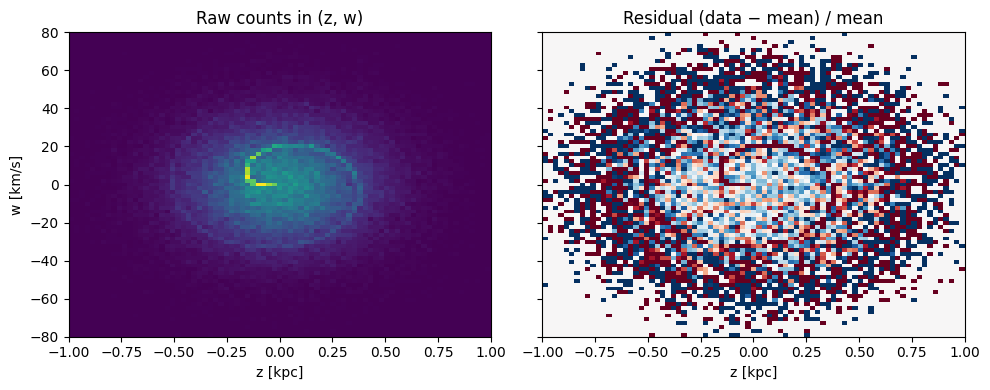

In [53]:
# import matplotlib.pyplot as plt
# import numpy as np
#
# # model without thin DD, just to focus on the spiral mechanics
# model = VerticalThinDiskModel(
#     rho_bkg0_pc=0.10,
#     Sigma_DD=0.0,      # no thin dark disk here
#     h_DD_pc=50.0,
#     sigma_z=20.0,
#     alpha=0.05,        # quite weak winding
#     t_mix=1.0
# )
#
# N = 80_000
# z_data, w_data, z_smooth, w_smooth = model.simulate_data_with_weak_spiral(
#     N,
#     frac_spiral=0.05,   # only 8% spiral component -> low contrast
#     seed=None
# )
#
# # 2D histograms on the same grid
# z_bins = np.linspace(-1.0, 1.0, 80)
# w_bins = np.linspace(-80.0, 80.0, 80)
#
# H_data, z_edges, w_edges = np.histogram2d(z_data,   w_data,   bins=[z_bins, w_bins])
# H_mean, _, _             = np.histogram2d(z_smooth, w_smooth, bins=[z_bins, w_bins])
#
# eps = 1e-3
# R = (H_data - H_mean) / (H_mean + eps)   # relative residual
#
# fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
#
# # 1) absolute counts: should look like a smooth blob, spiral is very hard to see
# im0 = axes[0].pcolormesh(z_edges, w_edges, H_data.T)
# axes[0].set_title("Raw counts in (z, w)")
# axes[0].set_xlabel("z [kpc]")
# axes[0].set_ylabel("w [km/s]")
#
# # 2) relative to mean: spiral pops out
# im1 = axes[1].pcolormesh(z_edges, w_edges, R.T,
#                          vmin=-0.3, vmax=0.3, cmap="RdBu_r")
# axes[1].set_title("Residual (data − mean) / mean")
# axes[1].set_xlabel("z [kpc]")
#
# plt.tight_layout()
# plt.show()


# My code for the simulations #

In [2]:
# import numpy as np
# import scipy as sc
# import scipy.integrate as integ
# from dataclasses import dataclass
# from typing import Optional
# import math
#
#
# @dataclass
# class VerticalThinDiskModel:
#     # Potential parameters
#     rho_bkg0_pc: float = 0.10   # Msun / pc^3  (baryons + halo)
#     rho_DD0_pc: float = 0.01            # Msun / pc^3  (baryons + halo)
#     G: float = 4.3e-3           #
#     Sigma_DD:   float = 6     # Msun / pc^2  (thin dark disc; 0 = none)
#     h_DD_pc:    float = 50.0    # pc
#     A: float = 300              # bkg scale height in the potential
#     # Tracer dispersion
#     sigma_z: float = 20.0       # km/s
#     # Geometry
#     z_max_pc: float = 1000.0   # half-range in pc
#     n_z: int = 2001            # number of grid points in z
#     N_stars: int = 100_000     # number of stars to sample
#
#     # z_grid will be created after init, from z_max_pc and n_z
#     # (so you don't declare it with a default like np.linspace(...))
#
#     def __post_init__(self):
#         # here: z is in pc, covering [-z_max, +z_max]
#         self.z_grid = np.linspace(-self.z_max_pc,
#                                   +self.z_max_pc,
#                                   self.n_z)
#         self.rho_DD0_pc = self.Sigma_DD / (2.0 * self.h_DD_pc) if self.Sigma_DD > 0 else 0.0
#         self.E_grid, self.P_grid, self.z_turn = self.period_one_cycle(n_e_grid=300)
#
#     def _phi_bkg(self, z):
#         phi_bkg = 4 * np.pi * self.G * self.rho_bkg0_pc * self.A**2 * np.log(np.cosh(z) / self.A)
#         return phi_bkg
#     def _phi_dd(self, z):
#         if self.Sigma_DD == 0:
#             return 0.0
#         z = np.asarray(z)
#         return (4 * np.pi * self.G * self.rho_DD0_pc *
#                 self.h_DD_pc**2 * np.log(np.cosh(z / self.h_DD_pc)))
#     def phi_tot(self, z):
#         return self._phi_bkg(z) + self._phi_dd(z)
#     def E_z(self, z, w):
#         return self.phi_tot(z) + w**2/2
#
#     def df_equilibrium_sampling(self, N, seed:Optional[float]=None):
#         rho_arr = np.exp(-self.phi_tot(self.z_grid) / self.sigma_z**2)
#         norm_rho = np.sum(rho_arr)
#         p_i = rho_arr / norm_rho
#         z_samples = np.random.choice(self.z_grid, size=N, p=p_i)
#         w_samples = np.random.normal(size=N, loc=0.0, scale=self.sigma_z)
#         return z_samples, w_samples
#
#     def period_one_cycle(self, n_e_grid: int = 300):
#
#         z_min = 0
#         z_max = 0.99 * self.z_max_pc
#         z_turn = np.linspace(z_min, z_max, n_e_grid)
#         E_grid = self.phi_tot(z_turn)
#
#         P_grid = np.zeros_like(E_grid)
#
#         for k, (E_k, z_max_k) in enumerate(zip(E_grid, z_turn)):
#
#             mask = (self.z_grid >= 0.0) & (self.z_grid <= z_max_k)
#             z_slice = self.z_grid[mask]                 # 1D array of z from 0 to z_max_k
#             phi_slice = self.phi_tot(z_slice)           # Phi(z) on this slice
#
#
#             diff = E_k - phi_slice                      # should be >= 0 in this range
#             diff = np.clip(diff, 0.0, None)
#
#             integrand = 1.0 / np.sqrt(2.0 * diff)       # units: pc / (km/s)
#
#             t_quarter = integ.trapezoid(integrand, z_slice)    # integrate over z
#
#             # 4c. full period = 4 * quarter
#             P_grid[k] = 4.0 * t_quarter
#
#         return E_grid, P_grid, z_turn
#
#     def period_from_energy(self, E):
#         E = np.asarray(E)
#         P = np.interp(E, self.E_grid, self.P_grid)
#         return P
#
#
#     def map_zw_to_angle(self, z, w, n_e_grid_map: int = 300):
#         E_z = self.E_z(z, w)
#         P = self.period_from_energy(E=E_z)
#         tau = np.zeros_like(E_z)
#         for k, (E_k, z_i) in enumerate(zip(E_z, z)):
#             z_abs = np.abs(z_i)
#             mask = (self.z_grid >= 0.0) & (self.z_grid <= z_abs)
#             z_slice = self.z_grid[mask]                 # 1D array of z from 0 to z_max_k
#             phi_slice = self.phi_tot(z_slice)           # Phi(z) on this slice
#
#             diff = E_k - phi_slice                      # should be >= 0 in this range
#             diff = np.clip(diff, 0.0, None)
#             integrand = 1.0 / np.sqrt(2.0 * diff)       # units: pc / (km/s)
#             tau[k] = integ.trapezoid(integrand, z_slice)    # integrate over z
#
#
#         phi = np.empty_like(z, dtype=float)
#         q1 = (z > 0) & (w > 0)   # up, above plane
#         q2 = (z > 0) & (w < 0)   # down, above plane
#         q3 = (z < 0) & (w < 0)   # down, below plane
#         q4 = (z < 0) & (w > 0)   # up, below plane
#
#         t = np.empty_like(z, dtype=float)
#
#         t[q1] = tau[q1]
#         t[q2] = 0.5 * P[q2] - tau[q2]
#         t[q3] = 0.5 * P[q3] + tau[q3]
#         t[q4] = P[q4] - tau[q4]
#
#         # If you have exact z=0 cases, you can set them separately:
#         mask_plane = (z == 0)
#         t[mask_plane] = 0.0  # define as reference
#
#         # Now convert time to angle in [0, 2π)
#         phi = (2.0 * np.pi * t / P) % (2.0 * np.pi)
#         return phi
#
#


In [1]:
# import numpy as np
# from dataclasses import dataclass
# from typing import Optional
# import math
# import matplotlib.pyplot as plt
#
#
# @dataclass
# class VerticalSpiralSimulator:
#     # Background mass density (baryons + halo) at mid-plane
#     rho_bkg0_pc: float = 0.10      # Msun / pc^3
#
#     # Thin dark disc parameters
#     rho_DD0_pc: float = 0.0        # Msun / pc^3 (will be overridden if Sigma_DD > 0)
#     Sigma_DD: float = 0.0          # Msun / pc^2 (thin dark disk surface density)
#     h_DD_pc: float = 50.0          # pc (thin dark disk scale height)
#
#     # Background potential scale height
#     A_pc: float = 300.0            # pc
#
#     # Tracer dispersion
#     sigma_z: float = 20.0          # km/s
#
#     # Gravity (pc (km/s)^2 / Msun)
#     G: float = 4.3009e-3
#
#     # Geometry / grids
#     z_max_pc: float = 1000.0       # |z| max used in model (pc)
#     n_z: int = 2001                # size of z-grid used for DF sampling etc.
#
#     def __post_init__(self):
#         # z-grid used internally for equilibrium density/DF etc.
#         self.z_grid = np.linspace(-self.z_max_pc, self.z_max_pc, self.n_z)
#
#         # If Sigma_DD is given, override rho_DD0 so they are consistent
#         if self.Sigma_DD > 0.0:
#             self.rho_DD0_pc = self.Sigma_DD / (2.0 * self.h_DD_pc)
#
#         # Total mid-plane density and corresponding vertical frequency
#         self.rho_tot0_pc = self.rho_bkg0_pc + self.rho_DD0_pc
#         self.nu = math.sqrt(4.0 * math.pi * self.G * self.rho_tot0_pc)  # km/s per pc
#
#     # ------------- potentials (in (km/s)^2) -------------
#
#     def phi_bkg(self, z):
#         """Background log-cosh potential."""
#         z = np.asarray(z)
#         return (
#             4.0
#             * math.pi
#             * self.G
#             * self.rho_bkg0_pc
#             * (self.A_pc ** 2)
#             * np.log(np.cosh(z / self.A_pc))
#         )
#
#     def phi_dd(self, z):
#         """Thin dark disc log-cosh potential (or zero if Sigma_DD == 0)."""
#         if self.Sigma_DD <= 0.0:
#             # preserve shape of z
#             z = np.asarray(z)
#             return np.zeros_like(z, dtype=float)
#         z = np.asarray(z)
#         return (
#             4.0
#             * math.pi
#             * self.G
#             * self.rho_DD0_pc
#             * (self.h_DD_pc ** 2)
#             * np.log(np.cosh(z / self.h_DD_pc))
#         )
#
#     def phi_tot(self, z):
#         """Total vertical potential Φ(z) = Φ_bg + Φ_DD."""
#         return self.phi_bkg(z) + self.phi_dd(z)
#
#     # ------------- basic vertical energy -------------
#
#     def vertical_energy(self, z, w):
#         """Vertical energy per unit mass: E_z = Φ(z) + w^2/2."""
#         return self.phi_tot(z) + 0.5 * w**2
#
#     # ------------- equilibrium DF sampling -------------
#
#     def sample_equilibrium(self, N: int, seed: Optional[int] = None):
#         """
#         Sample N stars from the isothermal equilibrium DF:
#             rho(z) ∝ exp[-Φ(z) / σ_z^2],
#             w | z ~ N(0, σ_z^2).
#         Returns: (z_samples, w_samples).
#         """
#         rng = np.random.default_rng(seed)
#
#         # unnormalized density on the z-grid
#         phi_vals = self.phi_tot(self.z_grid)
#         rho_unnorm = np.exp(-phi_vals / (self.sigma_z ** 2))
#
#         # discrete PDF over z_grid
#         p = rho_unnorm / rho_unnorm.sum()
#
#         # sample z on the grid (this is the CDF method under the hood)
#         z_samples = rng.choice(self.z_grid, size=N, p=p)
#
#         # for each z, w ~ Gaussian with dispersion sigma_z
#         w_samples = rng.normal(loc=0.0, scale=self.sigma_z, size=N)
#
#         return z_samples, w_samples
#
#     # ------------- spiral DF sampling (angle–action toy) -------------
#
#     def sample_spiral(
#         self,
#         N: int,
#         epsilon: float = 0.10,    # spiral contrast (0 → no spiral, ∼0.1–0.2 gives weak spiral)
#         alpha: float = 0.10,      # dΩ/dJ strength (dimensionless slope)
#         sigma_theta: float = 0.35, # width of ridge in angle (radians)
#         t_mix: float = 3.0,       # "time since kick" in arbitrary units
#         seed: Optional[int] = None,
#     ):
#         """
#         Sample N stars from a DF of the form
#             f(J, θ) ∝ exp[-Ω0 J / σ_z^2]  [equilibrium]
#                       × [1 + ε g(J, θ)]   [spiral overdensity]
#         where g is a Gaussian ridge in θ around θ_ridge(J) = Ω(J) t_mix.
#
#         Uses a simple harmonic-oscillator approximation for mapping (J, θ) → (z, w):
#             z = √(2J/Ω0) sin θ
#             w = √(2JΩ0) cos θ
#
#         Returns: (z_spiral, w_spiral).
#         """
#         rng = np.random.default_rng(seed)
#
#         Omega0 = self.nu  # base vertical frequency from mid-plane density
#         J0 = self.sigma_z ** 2 / Omega0  # characteristic action scale
#
#         N_target = N
#         N_draw = int(N_target * 2.0)  # oversample for rejection
#
#         z_accum = []
#         w_accum = []
#         n_acc = 0
#
#         while n_acc < N_target:
#             # base DF in J: exponential, f0 ~ exp(-Ω0 J / σ_z^2)
#             u = rng.random(N_draw)
#             J = - (self.sigma_z ** 2 / Omega0) * np.log(1.0 - u)
#
#             # uniform angle θ
#             theta = rng.uniform(0.0, 2.0 * math.pi, size=N_draw)
#
#             # energy-dependent frequency Ω(J)
#             Omega = Omega0 * (1.0 + alpha * (J / J0))
#
#             # ridge angle at time t_mix (kick at θ=0)
#             theta_ridge = Omega * t_mix
#
#             # wrapped angle difference in [-π, π]
#             dtheta = (theta - theta_ridge + math.pi) % (2.0 * math.pi) - math.pi
#
#             # Gaussian modulation along the ridge
#             g = np.exp(-0.5 * (dtheta / sigma_theta) ** 2)
#
#             # weights: 1 + ε g, max ≈ 1 + ε
#             w_mod = 1.0 + epsilon * g
#             p_accept = w_mod / (1.0 + epsilon)
#
#             # rejection sampling
#             accept = rng.random(N_draw) < p_accept
#             J_acc = J[accept]
#             theta_acc = theta[accept]
#
#             if J_acc.size == 0:
#                 continue
#
#             # map to (z, w) using harmonic-orbit approximation
#             A = np.sqrt(2.0 * J_acc / Omega0)
#             z_tmp = A * np.sin(theta_acc)
#             w_tmp = A * Omega0 * np.cos(theta_acc)
#
#             # |z| cut like Gaia region
#             mask = np.abs(z_tmp) < self.z_max_pc
#             z_tmp = z_tmp[mask]
#             w_tmp = w_tmp[mask]
#
#             z_accum.append(z_tmp)
#             w_accum.append(w_tmp)
#             n_acc += z_tmp.size
#
#         z_all = np.concatenate(z_accum)[:N_target]
#         w_all = np.concatenate(w_accum)[:N_target]
#         return z_all, w_all
#
#
#     # ------------- pure spiral DF (no background) -------------
#
#     def sample_pure_spiral(
#         self,
#         N: int,
#         alpha: float = 0.10,       # dΩ/dJ strength
#         sigma_theta: float = 0.15, # narrow ridge in angle [rad]
#         t_mix: float = 3.0,        # "time since kick" in arbitrary units
#         seed: Optional[int] = None,
#     ):
#         """
#         Sample N stars that lie *only* on a spiral ridge in (J, θ).
#         DF: f(J, θ) ∝ exp(-Ω0 J / σ_z^2) * Gaussian(θ - θ_ridge(J)),
#         with θ_ridge(J) = Ω(J) t_mix.
#
#         Mapping to (z, w) uses harmonic approximation:
#             z = √(2J/Ω0) sin θ
#             w = √(2JΩ0) cos θ
#         """
#         rng = np.random.default_rng(seed)
#
#         Omega0 = self.nu                  # base vertical frequency
#         J0 = self.sigma_z**2 / Omega0     # action scale
#
#         # Draw actions from exponential in J
#         u = rng.random(N)
#         J = - (self.sigma_z**2 / Omega0) * np.log(1.0 - u)
#
#         # Energy-dependent frequency Ω(J)
#         Omega = Omega0 * (1.0 + alpha * (J / J0))
#
#         # Ridge angle at time t_mix
#         theta_ridge = Omega * t_mix
#
#         # Draw angle near ridge: θ = θ_ridge + δθ, δθ ~ N(0, σ_θ^2)
#         dtheta = rng.normal(loc=0.0, scale=sigma_theta, size=N)
#         theta = theta_ridge + dtheta
#
#         # Wrap θ to [0, 2π)
#         theta = (theta + 2.0 * math.pi) % (2.0 * math.pi)
#
#         # Map (J, θ) → (z, w)
#         A = np.sqrt(2.0 * J / Omega0)
#         z = A * np.sin(theta)
#         w = A * Omega0 * np.cos(theta)
#
#         # |z| cut
#         mask = np.abs(z) < self.z_max_pc
#         return z[mask], w[mask]
#
#     # ------------- mixture: equilibrium + weak spiral -------------
#
#     def sample_data_with_spiral(
#         self,
#         N: int,
#         frac_spiral: float = 0.20,   # fraction of stars on the spiral
#         alpha: float = 0.10,
#         sigma_theta: float = 0.15,
#         t_mix: float = 3.0,
#         seed: Optional[int] = None,
#     ):
#         """
#         Sample a 'data' catalogue that is mostly equilibrium, with a small
#         spiral component mixed in:
#             data ≈ (1 - f) * equilibrium  +  f * pure_spiral
#
#         Returns:
#             z_data, w_data
#         """
#         rng = np.random.default_rng(seed)
#
#         N_spiral = int(N * frac_spiral)
#         N_eq = N - N_spiral
#
#         # Smooth equilibrium
#         z_eq, w_eq = self.sample_equilibrium(N_eq, seed=rng.integers(1e9))
#
#         # Pure spiral
#         z_sp, w_sp = self.sample_pure_spiral(
#             N_spiral,
#             alpha=alpha,
#             sigma_theta=sigma_theta,
#             t_mix=t_mix,
#             seed=rng.integers(1e9),
#         )
#
#         # Combine & shuffle
#         z_all = np.concatenate([z_eq, z_sp])
#         w_all = np.concatenate([w_eq, w_sp])
#
#         idx = rng.permutation(z_all.size)
#         return z_all[idx], w_all[idx]
#


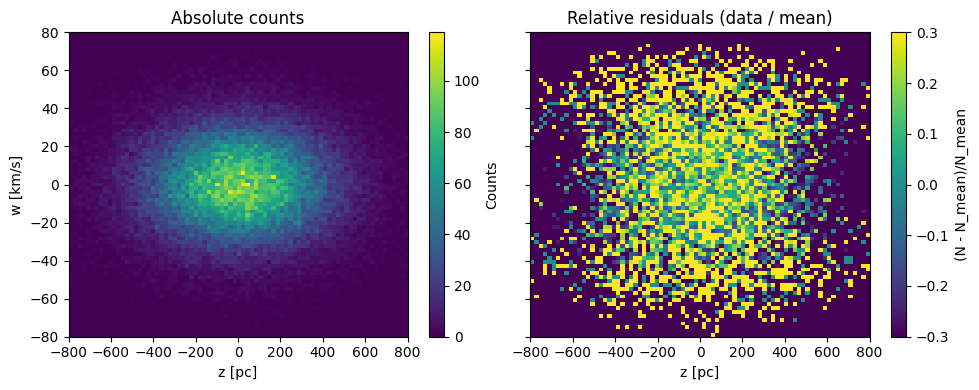

In [11]:
# if __name__ == "__main__":
#     # ------------------ set up model ------------------
#     model = VerticalSpiralSimulator(
#         rho_bkg0_pc=0.10,
#         Sigma_DD=0.0,       # 0 → no thin dark disk in the potential
#         h_DD_pc=50.0,
#         A_pc=300.0,
#         sigma_z=20.0,
#         z_max_pc=1000.0,
#         n_z=2001,
#     )
#
#     # number of stars
#     N = 80_000
#
#     # ------------------ simulate data ------------------
#     # Spiral ("data")
#     z_data, w_data = model.sample_spiral(
#         N,
#         epsilon=.4,     # spiral contrast
#         alpha=0.60,       # Ω(J) slope
#         sigma_theta=0.35,
#         t_mix=3000.0,
#         seed=123,
#     )
#
#     # Smooth equilibrium ("mean DF")
#     z_mean, w_mean = model.sample_equilibrium(N, seed=456)
#
#     # ------------------ make 2D histograms ------------------
#     # bins in pc and km/s
#     z_bins = np.linspace(-800.0, 800.0, 80)
#     w_bins = np.linspace(-80.0, 80.0, 80)
#
#     H_data, _, _ = np.histogram2d(z_data, w_data, bins=[z_bins, w_bins])
#     H_mean, _, _ = np.histogram2d(z_mean, w_mean, bins=[z_bins, w_bins])
#
#     # avoid divide-by-zero
#     H_mean_safe = H_mean + 1e-6
#
#     # residuals: (data - mean) / mean
#     R = (H_data - H_mean_safe) / H_mean_safe
#
#     # ------------------ plotting ------------------
#     fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
#
#     # absolute counts
#     im0 = axes[0].imshow(
#         H_data.T,
#         origin="lower",
#         aspect="auto",
#         extent=[z_bins[0], z_bins[-1], w_bins[0], w_bins[-1]],
#     )
#     axes[0].set_title("Absolute counts")
#     axes[0].set_xlabel("z [pc]")
#     axes[0].set_ylabel("w [km/s]")
#     fig.colorbar(im0, ax=axes[0], label="Counts")
#
#     # residuals
#     im1 = axes[1].imshow(
#         R.T,
#         origin="lower",
#         aspect="auto",
#         extent=[z_bins[0], z_bins[-1], w_bins[0], w_bins[-1]],
#         vmin=-0.3,
#         vmax=0.3,
#     )
#     axes[1].set_title("Relative residuals (data / mean)")
#     axes[1].set_xlabel("z [pc]")
#     fig.colorbar(im1, ax=axes[1], label="(N - N_mean)/N_mean")
#
#     plt.tight_layout()
#     plt.show()


In [1]:
# import numpy as np
# import math
# from dataclasses import dataclass
# from typing import Optional
# import matplotlib.pyplot as plt
#
#
# # ----------------------------------------------------------
# # Vertical thin-disk model + phase-space spiral generator
# # ----------------------------------------------------------
#
# @dataclass
# class VerticalThinDiskModel:
#     # --- mass model parameters (all in pc, Msun, km/s) ---
#     rho_bkg0_pc: float = 0.10     # Msun / pc^3 (baryons + halo mid-plane)
#     Sigma_DD: float = 0.0         # Msun / pc^2 (thin dark disk surface density)
#     h_DD_pc: float = 50.0         # pc (thin dark disk scale height)
#     A_pc: float = 300.0           # pc (background log-cosh scale height)
#
#     # tracer properties
#     sigma_z: float = 20.0         # km/s (vertical dispersion of tracer)
#
#     # gravitational constant in pc (km/s)^2 / Msun
#     G: float = 4.3009e-3
#
#     # geometry / grids
#     z_max_pc: float = 1000.0      # maximum |z| used in model (pc)
#     n_z: int = 2001               # number of grid points in z
#
#     def __post_init__(self):
#         # z grid used for equilibrium DF, etc.
#         self.z_grid = np.linspace(-self.z_max_pc, self.z_max_pc, self.n_z)
#
#         # consistent dark-disk mid-plane density (if Sigma_DD > 0)
#         if self.Sigma_DD > 0.0:
#             self.rho_DD0_pc = self.Sigma_DD / (2.0 * self.h_DD_pc)
#         else:
#             self.rho_DD0_pc = 0.0
#
#         # total mid-plane density & small-amplitude vertical frequency
#         self.rho_tot0_pc = self.rho_bkg0_pc + self.rho_DD0_pc
#         self.nu = math.sqrt(4.0 * math.pi * self.G * self.rho_tot0_pc)  # km/s per pc
#
#     # ----------------- potential and force -----------------
#
#     def phi_bkg(self, z):
#         """
#         Background log-cosh potential:
#             Φ_bg(z) = 4πG ρ_bkg0 A^2 ln cosh(z/A)
#         Returns Φ in (km/s)^2.
#         """
#         z = np.asarray(z, dtype=float)
#         return (
#             4.0 * math.pi * self.G * self.rho_bkg0_pc * self.A_pc**2
#             * np.log(np.cosh(z / self.A_pc))
#         )
#
#     def phi_dd(self, z):
#         """
#         Thin dark-disc potential (log-cosh) or zero if Sigma_DD == 0.
#         """
#         if self.Sigma_DD <= 0.0:
#             z = np.asarray(z, dtype=float)
#             return np.zeros_like(z)
#         z = np.asarray(z, dtype=float)
#         return (
#             4.0 * math.pi * self.G * self.rho_DD0_pc * self.h_DD_pc**2
#             * np.log(np.cosh(z / self.h_DD_pc))
#         )
#
#     def phi_tot(self, z):
#         """Total vertical potential Φ(z) = Φ_bg + Φ_DD."""
#         return self.phi_bkg(z) + self.phi_dd(z)
#
#     def dphi_dz(self, z):
#         """
#         dΦ/dz in (km/s)^2 per pc.
#         For log-cosh Φ = K a^2 ln cosh(z/a) we have dΦ/dz = K a tanh(z/a).
#         """
#         z = np.asarray(z, dtype=float)
#         term_bg = 4.0 * math.pi * self.G * self.rho_bkg0_pc * self.A_pc * np.tanh(z / self.A_pc)
#
#         if self.Sigma_DD > 0.0:
#             term_dd = 4.0 * math.pi * self.G * self.rho_DD0_pc * self.h_DD_pc * np.tanh(
#                 z / self.h_DD_pc
#             )
#         else:
#             term_dd = 0.0
#
#         return term_bg + term_dd
#
#     # ----------------- basic energy -----------------
#
#     def vertical_energy(self, z, w):
#         """Vertical specific energy: E_z = Φ(z) + 0.5 w^2 (units: (km/s)^2)."""
#         return self.phi_tot(z) + 0.5 * w**2
#
#     # ----------------- equilibrium sampling -----------------
#
#     def sample_equilibrium(self, N: int, seed: Optional[int] = None):
#         """
#         Sample N stars from the isothermal equilibrium DF:
#             ρ(z) ∝ exp(-Φ(z)/σ_z^2)
#             w | z ~ Normal(0, σ_z^2)
#         Returns: z_samples [pc], w_samples [km/s]
#         """
#         rng = np.random.default_rng(seed)
#
#         phi_vals = self.phi_tot(self.z_grid)
#         rho_unnorm = np.exp(-phi_vals / self.sigma_z**2)
#         p_i = rho_unnorm / rho_unnorm.sum()
#
#         z_samples = rng.choice(self.z_grid, size=N, p=p_i)
#         w_samples = rng.normal(loc=0.0, scale=self.sigma_z, size=N)
#
#         return z_samples, w_samples
#
#     # ----------------- coherent sheet (same phase) -----------------
#
#     def sample_coherent_sheet(self, N: int, z_phase_pc: int = 5, seed: Optional[int] = None):
#         """
#         Sample N stars all at the *same orbital phase*:
#             z = 0, w > 0 (mid-plane crossing, upward).
#         Energies E = w^2/2 follow an exponential ∝ exp(-E/σ_z^2).
#         """
#         rng = np.random.default_rng(seed)
#         # half-Gaussian: upward velocities only
#         z = rng.normal(loc=0.0, scale=z_phase_pc, size=N)
#         w = np.abs(rng.normal(loc=0.0, scale=self.sigma_z, size=N))
#         return z, w
#
#     # ----------------- orbit integration in Φ(z) -----------------
#
#     def integrate_orbits(self, z0, w0, t_tot, n_steps):
#         """
#         Integrate 1D vertical orbits in Φ(z) for time t_tot (in pc/(km/s))
#         with n_steps leapfrog steps.
#
#         z0, w0: arrays of initial positions/velocities (pc, km/s)
#         returns: z, w at t_tot
#         """
#         z = np.asarray(z0, dtype=float).copy()
#         w = np.asarray(w0, dtype=float).copy()
#         dt = t_tot / float(n_steps)
#
#         for _ in range(n_steps):
#             # half-kick
#             w -= 0.5 * dt * self.dphi_dz(z)
#             # drift
#             z += dt * w
#             # half-kick
#             w -= 0.5 * dt * self.dphi_dz(z)
#
#         return z, w
#
#     # ----------------- spiral from coherent sheet -----------------
#
#     def sample_spiral_from_sheet(
#         self,
#         N: int,
#         t_mix_factor: float = 2.5,   # evolve for ~t_mix_factor periods
#         n_steps_per_T: int = 400,
#         seed: Optional[int] = None,
#     ):
#         """
#         Construct a phase-space spiral by:
#           1. Putting all stars on the same phase (z=0, w>0),
#           2. Evolving them in the *true* Φ(z) for several vertical periods.
#         This creates a wound-up sheet in (z,w) because Ω(E) varies with E.
#
#         Returns: z_spiral, w_spiral (pc, km/s)
#         """
#         rng = np.random.default_rng(seed)
#
#         # 1. coherent sheet at t = 0
#         z0, w0 = self.sample_coherent_sheet(N, seed=rng.integers(1e9))
#
#         # 2. total integration time
#         T0 = 2.0 * math.pi / self.nu      # small-amplitude period (pc/(km/s))
#         t_tot = t_mix_factor * T0
#         n_steps = int(n_steps_per_T * t_mix_factor)
#
#         # 3. integrate
#         z_fin, w_fin = self.integrate_orbits(z0, w0, t_tot, n_steps)
#
#         # 4. restrict to |z| < z_max_pc
#         mask = np.abs(z_fin) < self.z_max_pc
#         return z_fin[mask], w_fin[mask]
#
#     # ----------------- mixture catalogue: data with spiral -----------------
#
#     def sample_data_with_spiral(
#         self,
#         N: int,
#         frac_spiral: float = 0.2,   # fraction of stars in the spiral component
#         t_mix_factor: float = 2.5,
#         n_steps_per_T: int = 400,
#         seed: Optional[int] = None,
#     ):
#         """
#         Build a 'data' catalogue that is mostly equilibrium, with a
#         fraction frac_spiral in a wound-up spiral.
#
#             data ≈ (1 - f) * equilibrium + f * spiral_from_sheet
#
#         Returns: z_data, w_data
#         """
#         rng = np.random.default_rng(seed)
#
#         N_spiral = int(frac_spiral * N)
#         N_eq = N - N_spiral
#
#         z_eq, w_eq = self.sample_equilibrium(N_eq, seed=rng.integers(1e9))
#         z_sp, w_sp = self.sample_spiral_from_sheet(
#             N_spiral,
#             t_mix_factor=t_mix_factor,
#             n_steps_per_T=n_steps_per_T,
#             seed=rng.integers(1e9),
#         )
#
#         z_all = np.concatenate([z_eq, z_sp])
#         w_all = np.concatenate([w_eq, w_sp])
#
#         # shuffle
#         idx = rng.permutation(z_all.size)
#         return z_all[idx], w_all[idx]
#


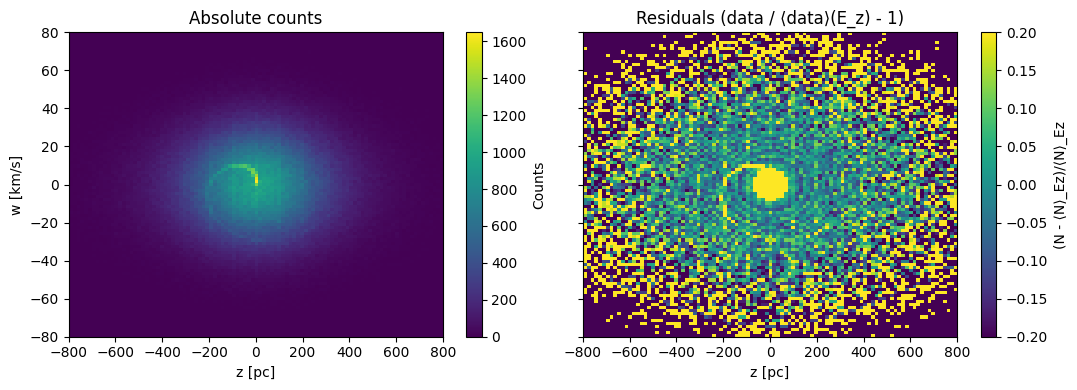

In [13]:
from mpmath import harmonic

# ----------------------------------------------------------
# Example usage: simulate & plot absolute vs residual spiral
# ----------------------------------------------------------
if __name__ == "__main__":
    model = VerticalThinDiskModel(
        rho_bkg0_pc=0.20,
        Sigma_DD=0.0,
        h_DD_pc=50.0,
        A_pc=300.0,
        sigma_z=20.0,
        z_max_pc=1000.0,
        n_z=2001,
    )

    N = 1000_000

    z_data, w_data = model.sample_data_with_spiral(
        N,
        frac_spiral=0.01,
        t_mix_factor=5,
        n_steps_per_T=2000,
        seed=None,
    )

    z_bins = np.linspace(-800.0, 800.0, 100)
    w_bins = np.linspace(-80.0, 80.0, 100)

    H_data, _, _ = np.histogram2d(z_data, w_data, bins=[z_bins, w_bins])

    # --- build mean(Ez) from H_data itself ---

    z_centers = 0.5 * (z_bins[:-1] + z_bins[1:])
    w_centers = 0.5 * (w_bins[:-1] + w_bins[1:])
    Zc, Wc = np.meshgrid(z_centers, w_centers, indexing="ij")

    Ez_grid = model.vertical_energy(Zc, Wc)
    Ez_flat = Ez_grid.ravel()
    H_flat = H_data.ravel()

    E_min = np.percentile(Ez_flat[H_flat > 0], 1)
    E_max = np.percentile(Ez_flat[H_flat > 0], 99)
    n_E = 50
    E_bins = np.linspace(E_min, E_max, n_E + 1)

    E_idx = np.digitize(Ez_flat, E_bins) - 1
    valid = (E_idx >= 0) & (E_idx < n_E)

    sum_counts = np.bincount(E_idx[valid], weights=H_flat[valid], minlength=n_E)
    n_pixels  = np.bincount(E_idx[valid], minlength=n_E)
    H_E = sum_counts / np.maximum(n_pixels, 1)

    H_mean_flat = np.zeros_like(H_flat, dtype=float)
    H_mean_flat[valid] = H_E[E_idx[valid]]
    H_mean = H_mean_flat.reshape(H_data.shape)

    H_mean_safe = H_mean + 1e-6
    R = (H_data - H_mean_safe) / H_mean_safe

    # --- plotting ---

    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)

    im0 = axes[0].imshow(
        H_data.T,
        origin="lower",
        aspect="auto",
        extent=[z_bins[0], z_bins[-1], w_bins[0], w_bins[-1]],
    )
    axes[0].set_title("Absolute counts")
    axes[0].set_xlabel("z [pc]")
    axes[0].set_ylabel("w [km/s]")
    fig.colorbar(im0, ax=axes[0], label="Counts")

    im1 = axes[1].imshow(
        R.T,
        origin="lower",
        aspect="auto",
        extent=[z_bins[0], z_bins[-1], w_bins[0], w_bins[-1]],
        vmin=-0.2,
        vmax=0.2,
    )
    axes[1].set_title("Residuals (data / ⟨data⟩(E_z) - 1)")
    axes[1].set_xlabel("z [pc]")
    fig.colorbar(im1, ax=axes[1], label="(N - ⟨N⟩_Ez)/⟨N⟩_Ez")

    plt.tight_layout()
    plt.show()


In [26]:
# import numpy as np
# import math
# from dataclasses import dataclass
# from typing import Optional, Tuple
# import matplotlib.pyplot as plt
# from sklearn.mixture import GaussianMixture
#
#
# @dataclass
# class Widmark1DSimulation:
#     # -------- mass model (similar to Table 2) --------
#     rho0_thin: float = 0.04    # Msun/pc^3
#     rho0_thick: float = 0.01   # Msun/pc^3
#     rho0_gas: float = 0.05     # Msun/pc^3
#     rho_DM: float = 0.01       # Msun/pc^3
#
#     # velocity dispersions of the three components (km/s)
#     sigma_w_thin: float = 16.0
#     sigma_w_thick: float = 24.0
#     sigma_w_gas: float = 8.0
#
#     # adopted scale heights for the three baryonic sheets (pc)
#     h_thin_pc: float = 200.0
#     h_thick_pc: float = 400.0
#     h_gas_pc: float = 800.0
#
#     # -------- satellite perturbation (Table 2 style) --------
#     Sigma_sat: float = 6.0     # Msun/pc^2
#     sigma_t_myr: float = 80.0  # Myr
#     H_sat_pc: float = 50.0     # pc
#     z0_sat_pc: float = 600.0   # pc
#     w_sat_kms: float = -50.0   # km/s
#
#     # -------- geometry / technical --------
#     z_max_pc: float = 1000.0   # range in z for sampling / plots
#     n_z: int = 2001            # grid points in z
#
#     # mask for plotting / inference (Eq. 21)
#     Z_lim_mask_pc: float = 700.0
#     W_lim_mask_kms: float = 40.0
#
#     # gravitational constant in pc (km/s)^2 / Msun
#     G: float = 4.3009e-3
#
#     def __post_init__(self):
#         self.z_grid = np.linspace(-self.z_max_pc, self.z_max_pc, self.n_z)
#         # 1 km/s ≈ 1.0227 pc/Myr → 1 Myr in internal units pc/(km/s)
#         self.MYR_TO_TUNIT = 1.022712
#
#     # ==========================================================
#     # background mass model: Φ(z) and dΦ/dz
#     # ==========================================================
#
#     def phi_component_sech2(self, z: np.ndarray, rho0: float, h_pc: float) -> np.ndarray:
#         """
#         Potential of a single sech^2 sheet:
#             rho(z) = rho0 / cosh^2(z/h)
#             Φ(z)   = 4πG rho0 h^2 ln cosh(z/h),  with Φ(0)=0.
#         """
#         z = np.asarray(z, dtype=float)
#         return 4.0 * math.pi * self.G * rho0 * h_pc**2 * np.log(np.cosh(z / h_pc))
#
#     def dphi_dz_component_sech2(self, z: np.ndarray, rho0: float, h_pc: float) -> np.ndarray:
#         """
#         dΦ/dz = 4πG rho0 h tanh(z/h)
#         """
#         z = np.asarray(z, dtype=float)
#         return 4.0 * math.pi * self.G * rho0 * h_pc * np.tanh(z / h_pc)
#
#     def phi_DM_const(self, z: np.ndarray) -> np.ndarray:
#         """Constant halo density ρ_DM ⇒ Φ_DM = 2πG ρ_DM z^2 (Φ(0)=0)."""
#         z = np.asarray(z, dtype=float)
#         return 2.0 * math.pi * self.G * self.rho_DM * z**2
#
#     def dphi_dz_DM_const(self, z: np.ndarray) -> np.ndarray:
#         """dΦ_DM/dz = 4πG ρ_DM z."""
#         z = np.asarray(z, dtype=float)
#         return 4.0 * math.pi * self.G * self.rho_DM * z
#
#     def phi_tot(self, z: np.ndarray) -> np.ndarray:
#         """Total potential of thin + thick + gas sheets + constant halo."""
#         return (
#             self.phi_component_sech2(z, self.rho0_thin, self.h_thin_pc)
#             + self.phi_component_sech2(z, self.rho0_thick, self.h_thick_pc)
#             + self.phi_component_sech2(z, self.rho0_gas, self.h_gas_pc)
#             + self.phi_DM_const(z)
#         )
#
#     def dphi_dz(self, z: np.ndarray) -> np.ndarray:
#         """Total dΦ/dz."""
#         return (
#             self.dphi_dz_component_sech2(z, self.rho0_thin, self.h_thin_pc)
#             + self.dphi_dz_component_sech2(z, self.rho0_thick, self.h_thick_pc)
#             + self.dphi_dz_component_sech2(z, self.rho0_gas, self.h_gas_pc)
#             + self.dphi_dz_DM_const(z)
#         )
#
#     # ==========================================================
#     # equilibrium sampling of the three components
#     # ==========================================================
#
#     def _sample_component_equilibrium(
#         self, N: int, sigma_w: float, rng: np.random.Generator
#     ) -> Tuple[np.ndarray, np.ndarray]:
#         """
#         Isothermal equilibrium DF for one component in the fixed Φ(z):
#             ρ(z) ∝ exp[-Φ(z)/σ_w^2]
#             w|z ~ N(0, σ_w)
#         """
#         phi_vals = self.phi_tot(self.z_grid)
#         rho_unnorm = np.exp(-phi_vals / sigma_w**2)
#         p_z = rho_unnorm / rho_unnorm.sum()
#
#         z_samples = rng.choice(self.z_grid, size=N, p=p_z)
#         w_samples = rng.normal(loc=0.0, scale=sigma_w, size=N)
#         return z_samples, w_samples
#
#     def sample_initial_particles(
#         self, N_total: int, seed: Optional[int] = None
#     ) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
#         """
#         Draw initial particles from thin+thick+gas equilibrium DFs.
#         Returns:
#             z0 [pc], w0 [km/s], comp_index (0=thin,1=thick,2=gas)
#         """
#         rng = np.random.default_rng(seed)
#
#         # allocate numbers per component ∝ mid-plane density
#         weights = np.array([self.rho0_thin, self.rho0_thick, self.rho0_gas], float)
#         weights /= weights.sum()
#         N_comp = rng.multinomial(N_total, weights)
#
#         z_list = []
#         w_list = []
#         comp_list = []
#
#         # thin
#         if N_comp[0] > 0:
#             z_t, w_t = self._sample_component_equilibrium(N_comp[0], self.sigma_w_thin, rng)
#             z_list.append(z_t)
#             w_list.append(w_t)
#             comp_list.append(np.zeros(N_comp[0], dtype=int))
#         # thick
#         if N_comp[1] > 0:
#             z_t, w_t = self._sample_component_equilibrium(N_comp[1], self.sigma_w_thick, rng)
#             z_list.append(z_t)
#             w_list.append(w_t)
#             comp_list.append(np.ones(N_comp[1], dtype=int))
#         # gas
#         if N_comp[2] > 0:
#             z_t, w_t = self._sample_component_equilibrium(N_comp[2], self.sigma_w_gas, rng)
#             z_list.append(z_t)
#             w_list.append(w_t)
#             comp_list.append(np.full(N_comp[2], 2, dtype=int))
#
#         z0 = np.concatenate(z_list)
#         w0 = np.concatenate(w_list)
#         comp_idx = np.concatenate(comp_list)
#
#         return z0, w0, comp_idx
#
#     # ==========================================================
#     # Satellite force Kz,sat and orbit integration
#     # ==========================================================
#
#     def Kz_sat_common(self, t_internal: float, z: np.ndarray) -> np.ndarray:
#         """
#         External satellite force (schematic of eq. 27):
#
#             Kz,sat(t,z) = -4πG Σ exp( -t^2 / (2 σ_t^2) ) *
#                            tanh( [z - (z0_sat + w_sat t)] / H )
#
#         t_internal is in pc/(km/s).
#         σ_t is given in Myr and converted via MYR_TO_TUNIT.
#         """
#         z = np.asarray(z, dtype=float)
#
#         sigma_t_internal = self.sigma_t_myr * self.MYR_TO_TUNIT
#         tau = t_internal / sigma_t_internal
#
#         z_sat = self.z0_sat_pc + self.w_sat_kms * t_internal  # pc
#
#         return (
#             -4.0 * math.pi * self.G * self.Sigma_sat
#             * np.exp(-0.5 * tau**2)
#             * np.tanh((z - z_sat) / self.H_sat_pc)
#         )
#
#     def evolve_with_satellite(
#         self,
#         z0: np.ndarray,
#         w0: np.ndarray,
#         t_obs_myr: float = 400.0,
#         n_steps: int = 10_000,
#         seed: Optional[int] = None,
#     ) -> Tuple[np.ndarray, np.ndarray]:
#         """
#         Evolve particles from t = -2.5 σ_t to t = t_obs under:
#             w_dot = -dΦ/dz + s_i Kz,sat(t,z)
#             z_dot = w
#
#         using a leapfrog-like scheme in internal time units pc/(km/s).
#
#         Returns final z, w at t_obs.
#         """
#         rng = np.random.default_rng(seed)
#         z = np.asarray(z0, dtype=float).copy()
#         w = np.asarray(w0, dtype=float).copy()
#
#         # per-particle scattering factors s_i ~ N(1, 0.5)
#         s_i = rng.normal(loc=1.0, scale=0.5, size=z.size)
#
#         sigma_t_internal = self.sigma_t_myr * self.MYR_TO_TUNIT
#         t_start = -2.5 * sigma_t_internal
#         t_end = t_obs_myr * self.MYR_TO_TUNIT
#         dt = (t_end - t_start) / float(n_steps)
#
#         t = t_start
#
#         # initial acceleration
#         a_bg = -self.dphi_dz(z)
#         if abs(t) <= 2.5 * sigma_t_internal:
#             a_sat = s_i * self.Kz_sat_common(t, z)
#         else:
#             a_sat = 0.0
#         a = a_bg + a_sat
#
#         # first half-kick
#         w += 0.5 * dt * a
#
#         for _ in range(n_steps):
#             # drift
#             z += dt * w
#             t += dt
#
#             # new acceleration
#             a_bg = -self.dphi_dz(z)
#             if abs(t) <= 2.5 * sigma_t_internal:
#                 a_sat = s_i * self.Kz_sat_common(t, z)
#             else:
#                 a_sat = 0.0
#             a = a_bg + a_sat
#
#             # kick
#             w += dt * a
#
#         # symmetric correction
#         w -= 0.5 * dt * a
#
#         return z, w
#
#     # ==========================================================
#     # Mask function M(Z,W) (Eq. 21) and histogram → spiral map
#     # ==========================================================
#
#     def mask_M(self, Z: np.ndarray, W: np.ndarray) -> np.ndarray:
#         """
#         Smooth circular mask in (Z,W), Eq. (21):
#
#         M(Z,W) = sigm( 10 * ( (Z/Z_lim)^2 + (W/W_lim)^2 - 1 ) )
#
#         with sigm(x) = 1/(1+exp(-x)).
#         """
#         Z = np.asarray(Z, dtype=float)
#         W = np.asarray(W, dtype=float)
#         r2 = (Z / self.Z_lim_mask_pc) ** 2 + (W / self.W_lim_mask_kms) ** 2
#         x = 10.0 * (r2 - 1.0)
#         return 1.0 / (1.0 + np.exp(-x))
#
#     def data_bulk_spiral_histograms(
#         self,
#         z_data: np.ndarray,
#         w_data: np.ndarray,
#         z_bins: np.ndarray,
#         w_bins: np.ndarray,
#         n_gmm: int = 6,
#         random_state: int = 0,
#     ):
#         """
#         Build 2D histogram d_ij of the data and a smooth bulk model B_ij
#         from a Gaussian Mixture fit, then construct the spiral map:
#
#             spiral_ij = M_ij * (d_ij - B_ij) / B_ij
#
#         This approximates Eq. (29) in Widmark+21, with Z_sun = W_sun = 0.
#         """
#         # 2D histogram of data
#         d, _, _ = np.histogram2d(z_data, w_data, bins=[z_bins, w_bins])
#
#         # Fit GMM to the point cloud
#         X = np.vstack([z_data, w_data]).T
#         gmm = GaussianMixture(
#             n_components=n_gmm, covariance_type="full", random_state=random_state
#         )
#         gmm.fit(X)
#
#         # Evaluate bulk model on bin centres
#         z_centers = 0.5 * (z_bins[:-1] + z_bins[1:])
#         w_centers = 0.5 * (w_bins[:-1] + w_bins[1:])
#         ZZ, WW = np.meshgrid(z_centers, w_centers, indexing="ij")
#         grid_points = np.column_stack([ZZ.ravel(), WW.ravel()])
#         bulk_pdf = np.exp(gmm.score_samples(grid_points)).reshape(ZZ.shape)
#
#         # Normalise pdf to match total counts inside mask
#         M = self.mask_M(ZZ, WW)
#         eps = 1e-12
#         data_sum = np.sum(M * d)
#         pdf_sum = np.sum(M * bulk_pdf)
#         B = bulk_pdf * (data_sum / (pdf_sum + eps))
#
#         spiral = M * (d - B) / (B + eps)
#
#         return d, B, spiral, M, ZZ, WW
#
#     # ==========================================================
#     # Convenience wrapper: build "data" and "mean" catalogues
#     # ==========================================================
#
#     def simulate_snapshot(
#         self,
#         N_particles: int = 100_000,
#         t_obs_myr: float = 400.0,
#         n_steps: int = 10_000,
#         seed_data: int = 1,
#         seed_mean: int = 2,
#     ):
#         """
#         Produce:
#           - 'data' catalogue: thin+thick particles after satellite perturbation
#           - 'mean' catalogue: thin+thick equilibrium (no satellite)
#
#         Returns:
#           (z_data, w_data), (z_mean, w_mean)
#         """
#         # initial state for data
#         z0, w0, comp_idx = self.sample_initial_particles(N_particles, seed=seed_data)
#         z_fin, w_fin = self.evolve_with_satellite(
#             z0, w0, t_obs_myr=t_obs_myr, n_steps=n_steps, seed=seed_data + 12345
#         )
#
#         # keep only thin+thick (comp 0 and 1) as "observed"
#         mask_stars = comp_idx != 2
#         z_data = z_fin[mask_stars]
#         w_data = w_fin[mask_stars]
#
#         # independent equilibrium (no satellite) for the mean
#         z_mean_all, w_mean_all, comp_mean = self.sample_initial_particles(
#             N_particles, seed=seed_mean
#         )
#         mask_stars_mean = comp_mean != 2
#         z_mean = z_mean_all[mask_stars_mean]
#         w_mean = w_mean_all[mask_stars_mean]
#
#         return (z_data, w_data), (z_mean, w_mean)
#
#     # ==========================================================
#     # Helpers for analytic spirals (Figs. 1 & 2 of Widmark+21)
#     # ==========================================================
#
#     def _phi_dphi_from_components(
#         self,
#         components: Tuple[Tuple[float, float], ...],
#         scale: float = 1.0,
#     ):
#         """
#         Build Φ(z), dΦ/dz for a sum of sech^2 components:
#
#             ρ(z) = Σ_i [ ρ0_i / cosh^2(z/h_i) ]
#
#         Parameters
#         ----------
#         components : tuple of (rho0, h_pc)
#             Densities [Msun/pc^3] and scale heights [pc].
#         scale : float
#             Overall multiplicative factor on the densities (for spiral B).
#
#         Returns
#         -------
#         phi(z), dphi_dz(z) : callables taking numpy arrays.
#         """
#
#         scaled = [(scale * rho0, h_pc) for (rho0, h_pc) in components]
#
#         def phi(z):
#             z = np.asarray(z, dtype=float)
#             total = np.zeros_like(z)
#             for rho0, h_pc in scaled:
#                 total += self.phi_component_sech2(z, rho0, h_pc)
#             return total
#
#         def dphi_dz(z):
#             z = np.asarray(z, dtype=float)
#             total = np.zeros_like(z)
#             for rho0, h_pc in scaled:
#                 total += self.dphi_dz_component_sech2(z, rho0, h_pc)
#             return total
#
#         return phi, dphi_dz
#
#     def _integrate_orbits_static(
#         self,
#         phi_fn,
#         dphi_dz_fn,
#         w0_grid: np.ndarray,
#         t_end_myr: float,
#         n_steps: int = 20000,
#         track_index: int = 0,
#     ):
#         w0_grid = np.asarray(w0_grid, dtype=float)
#         N_orb = w0_grid.size
#
#         # Internal time units
#         t_end_internal = t_end_myr * self.MYR_TO_TUNIT
#         dt = t_end_internal / float(n_steps)
#
#         # Initial conditions: all start at z=0 with w=w0 > 0
#         z = np.zeros(N_orb, dtype=float)
#         w = w0_grid.copy()
#
#         # Initial acceleration
#         a = -dphi_dz_fn(z)
#
#         # Leapfrog: half-kick
#         w += 0.5 * dt * a
#
#         # For the tracked orbit, store its trajectory
#         track_idx = int(track_index) % N_orb
#         z_traj = [z[track_idx]]
#         w_traj = [w[track_idx]]  # after half-kick; good enough for plotting
#
#         for _ in range(n_steps):
#             # Drift
#             z += dt * w
#
#             # New acceleration
#             a = -dphi_dz_fn(z)
#
#             # Kick
#             w += dt * a
#
#             # Save trajectory of the tracked orbit
#             z_traj.append(z[track_idx])
#             w_traj.append(w[track_idx])
#
#         # Final symmetric half-kick correction
#         w -= 0.5 * dt * a
#
#         return z, w, np.array(z_traj), np.array(w_traj)
#
#     def plot_analytic_spiral(
#         self,
#         t_fig1_myr: float = 600.0,
#         t_fig2_myr: float = 600.0,
#         *,
#         n_orbits: int = 120,          # more orbits → smoother spiral curve
#         n_steps_orbit: int = 20_000,  # more steps → smoother individual orbits
#         n_z_force: int = 800,         # sampling for Kz(z)
#         dpi: int = 150,               # figure resolution
#     ):
#         """
#         Make illustrative plots analogous to Figs. 1 and 2 in Widmark+21.
#
#         Resolution controls (all dynamic):
#           - n_orbits:     number of different energies / initial w0 values.
#           - n_steps_orbit:leapfrog steps per orbit.
#           - n_z_force:    sampling points for z in Kz(z).
#           - dpi:          Matplotlib figure DPI (export resolution).
#         """
#         #
#         # # ------------------------------------------------------
#         # # 1) Fig. 1-style spiral (potential from Eq. 7)
#         # # ------------------------------------------------------
#         # comps_fig1 = ((0.06, 200.0), (0.03, 400.0))
#         # phi1, dphi1 = self._phi_dphi_from_components(comps_fig1)
#         #
#         # w0_grid = np.linspace(5.0, 55.0, n_orbits)  # km/s
#         #
#         # zf1, wf1, z_track1, w_track1 = self._integrate_orbits_static(
#         #     phi1, dphi1, w0_grid, t_end_myr=t_fig1_myr,
#         #     n_steps=n_steps_orbit, track_index=n_orbits // 2
#         # )
#         #
#         # idx = np.argsort(w0_grid)
#         # z_spiral1 = zf1[idx]
#         # w_spiral1 = wf1[idx]
#         #
#         # fig1, ax1 = plt.subplots(figsize=(6, 5), dpi=dpi)
#         # ax1.plot(z_spiral1, w_spiral1, lw=2, label="Spiral (Fig.1-like)")
#         # ax1.plot(z_track1, w_track1, ls="--", lw=1.0, color="grey",
#         #          label="Single orbit trajectory")
#         #
#         # for j in [5, n_orbits // 2, n_orbits - 6]:
#         #     ax1.scatter(zf1[j], wf1[j], s=30,
#         #                 label=f"E index {j}" if j == 5 else None)
#         #
#         # ax1.set_xlabel("z [pc]")
#         # ax1.set_ylabel("w [km s$^{-1}$]")
#         # ax1.set_title("Analytic spiral – Fig. 1 style")
#         # ax1.legend(loc="upper right", fontsize=9)
#         # ax1.grid(alpha=0.3)
#
#         # ------------------------------------------------------
#         # 2) Fig. 2-style spirals for three potentials A, B, C
#         # ------------------------------------------------------
#         comps_A = ((0.05, 200.0), (0.02, 400.0), (0.02, 800.0))
#         comps_C = ((0.10, 100.0), (0.02, 400.0), (0.02, 800.0))
#
#         phiA, dphiA = self._phi_dphi_from_components(comps_A, scale=1.0)
#         phiB, dphiB = self._phi_dphi_from_components(comps_A, scale=1.5)
#         phiC, dphiC = self._phi_dphi_from_components(comps_C, scale=1.0)
#
#         z_force = np.linspace(0.0, 1000.0, n_z_force)
#         Kz_A = np.abs(-dphiA(z_force)) * self.MYR_TO_TUNIT
#         Kz_B = np.abs(-dphiB(z_force)) * self.MYR_TO_TUNIT
#         Kz_C = np.abs(-dphiC(z_force)) * self.MYR_TO_TUNIT
#
#         fig2, ax = plt.subplots(
#             1, 1, figsize=(8,5),
#             dpi=dpi,
#         )
#
#         # ax_top.plot(z_force, Kz_A, label="Spiral A")
#         # ax_top.plot(z_force, Kz_B, label="Spiral B")
#         # ax_top.plot(z_force, Kz_C, label="Spiral C")
#         # ax_top.set_ylabel(r"$|K_z|$ [km s$^{-1}$ Myr$^{-1}$]")
#         # ax_top.set_title("Vertical force and phase-space spirals – Fig. 2 style")
#         # ax_top.legend(loc="upper left", fontsize=9)
#         # ax_top.grid(alpha=0.3)
#
#         w0_grid = np.linspace(5.0, 55.0, n_orbits)
#
#         zA, wA, _, _ = self._integrate_orbits_static(
#             phiA, dphiA, w0_grid, t_end_myr=t_fig2_myr,
#             n_steps=n_steps_orbit, track_index=0
#         )
#         zB, wB, _, _ = self._integrate_orbits_static(
#             phiB, dphiB, w0_grid, t_end_myr=t_fig2_myr,
#             n_steps=n_steps_orbit, track_index=0
#         )
#         zC, wC, _, _ = self._integrate_orbits_static(
#             phiC, dphiC, w0_grid, t_end_myr=t_fig2_myr,
#             n_steps=n_steps_orbit, track_index=0
#         )
#
#         idx = np.argsort(w0_grid)
#         ax.plot(zA[idx], wA[idx], label="Spiral A")
#         ax.plot(zB[idx], wB[idx], label="Spiral B")
#         ax.plot(zC[idx], wC[idx], label="Spiral C")
#         ax.set_xlabel("z [pc]")
#         ax.set_ylabel("w [km s$^{-1}$]")
#         ax.legend(loc="upper right", fontsize=9)
#         ax.grid(alpha=0.3)
#
#         plt.tight_layout()
#         plt.show()
#
#
#
# def recenter(z, w):
#     return z - np.mean(z), w - np.mean(w)
#
#
# # ==============================================================
# # Example usage: absolute & relative phase space
# # ==============================================================
#
#


In [15]:
# sim = Widmark1DSimulation(
#     rho0_thin=0.04,
#     rho0_thick=0.01,
#     rho0_gas=0.05,
#     rho_DM=0.01,
#     sigma_w_thin=16.0,
#     sigma_w_thick=24.0,
#     sigma_w_gas=8.0,
#     Sigma_sat=6.0,       # you can tweak this to weaken/strengthen the spiral
#     sigma_t_myr=40.0,
#     H_sat_pc=50.0,
#     z0_sat_pc=600.0,
#     w_sat_kms=-50.0,
#     z_max_pc=1000.0,
#     n_z=2001,
# )
#
# # N = 100_000
# #
# # (z_data, w_data), (z_mean, w_mean) = sim.simulate_snapshot(
# #     N_particles=N,
# #     t_obs_myr=400.0,
# #     n_steps=10_000,
# # )
# #
# # # subtract bulk bending/breathing motion
# # z_data, w_data = recenter(z_data, w_data)
# #
# # # histogram bins: (20 pc) × (1 km/s), over [-900,900]×[-80,80]
# # z_bins = np.arange(-900.0, 900.0 + 20.0, 20.0)
# # w_bins = np.arange(-80.0, 80.0 + 1.0, 1.0)
# #
# # d, B, spiral, M, ZZ, WW = sim.data_bulk_spiral_histograms(
# #     z_data, w_data, z_bins, w_bins, n_gmm=6
# # )
# #
# # # Plot: absolute counts (panel b analogue) and residual spiral (panel c analogue)
# # fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)
# # extent = [z_bins[0], z_bins[-1], w_bins[0], w_bins[-1]]
# #
# # im0 = axes[0].imshow(
# #     d.T,
# #     origin="lower",
# #     aspect="auto",
# #     extent=extent,
# # )
# # axes[0].set_title("Data histogram (thin+thick)")
# # axes[0].set_xlabel("Z [pc]")
# # axes[0].set_ylabel("W [km/s]")
# # fig.colorbar(im0, ax=axes[0], label="Counts")
# #
# # im1 = axes[1].imshow(
# #     spiral.T,
# #     origin="lower",
# #     aspect="auto",
# #     extent=extent,
# #     vmin=-0.3,
# #     vmax=0.3,
# # )
# # axes[1].set_title("Mask × (Data - Bulk)/Bulk")
# # axes[1].set_xlabel("Z [pc]")
# # fig.colorbar(im1, ax=axes[1], label="Relative overdensity")
# #
# # plt.tight_layout()
# # plt.show()
# #
# #
# #
# #
# #
#
# sim.plot_analytic_spiral(
#     n_orbits=200,
#     n_steps_orbit=40_000,
#     n_z_force=1200,
#     dpi=150,
# )


# Simulate The Phase Space Spiral #

In [ ]:
import numpy as np
import math
from dataclasses import dataclass
from typing import Optional, Tuple

# --- analysis / plotting imports kept OUTSIDE the simulation core ---
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from sklearn.mixture import GaussianMixture


# ==========================================================
# Core: physics + sampling + integration (NO plotting)
# ==========================================================
import numpy as np
import math
from dataclasses import dataclass
from typing import Optional, Tuple


# ==========================================================
# Core: physics + sampling + integration (NO plotting)
# Time convention: we start at t=0 and integrate forward.
# Satellite pulse peaks at t=0 and decays for t>0.
# ==========================================================
@dataclass
class Widmark1DSimulation:
    # -------- mass model --------
    rho0_thin: float = 0.04    # Msun/pc^3
    rho0_thick: float = 0.01   # Msun/pc^3
    rho0_gas: float = 0.05     # Msun/pc^3
    rho_DM: float = 0.01       # Msun/pc^3

    # velocity dispersions (km/s)
    sigma_w_thin: float = 16.0
    sigma_w_thick: float = 24.0
    sigma_w_gas: float = 8.0

    # scale heights (pc)
    h_thin_pc: float = 200.0
    h_thick_pc: float = 400.0
    h_gas_pc: float = 800.0

    # -------- satellite perturbation --------
    Sigma_sat: float = 6.0     # Msun/pc^2
    sigma_t_myr: float = 80.0  # Myr (pulse width)
    H_sat_pc: float = 50.0     # pc
    z0_sat_pc: float = 600.0   # pc (satellite position at t=0)
    w_sat_kms: float = -50.0   # km/s (satellite vertical speed)

    # -------- geometry / technical --------
    z_max_pc: float = 1000.0
    n_z: int = 2001

    # survey window / mask params (used by analysis class)
    Z_lim_mask_pc: float = 700.0
    W_lim_mask_kms: float = 40.0

    # gravitational constant in pc (km/s)^2 / Msun
    G: float = 4.3009e-3

    def __post_init__(self):
        self.z_grid = np.linspace(-self.z_max_pc, self.z_max_pc, self.n_z)
        # 1 km/s ≈ 1.0227 pc/Myr  ->  1 Myr = 1.0227 pc/(km/s)
        self.MYR_TO_TUNIT = 1.022712

    # ==========================================================
    # Background Φ(z) and dΦ/dz
    # ==========================================================
    def dphi_dz_harmonic(self, z: np.ndarray, rho0=rho_DM) -> np.ndarray:
        z = np.asarray(z, dtype=float)
        return 4.0 * math.pi * self.G * rho0 * z

    def phi_component_sech2(self, z: np.ndarray, rho0: float, h_pc: float) -> np.ndarray:
        z = np.asarray(z, dtype=float)
        return 4.0 * math.pi * self.G * rho0 * h_pc**2 * np.log(np.cosh(z / h_pc))

    def dphi_dz_component_sech2(self, z: np.ndarray, rho0: float, h_pc: float) -> np.ndarray:
        z = np.asarray(z, dtype=float)
        return 4.0 * math.pi * self.G * rho0 * h_pc * np.tanh(z / h_pc)

    def phi_DM_const(self, z: np.ndarray) -> np.ndarray:
        z = np.asarray(z, dtype=float)
        return 2.0 * math.pi * self.G * self.rho_DM * z**2

    def dphi_dz_DM_const(self, z: np.ndarray) -> np.ndarray:
        z = np.asarray(z, dtype=float)
        return 4.0 * math.pi * self.G * self.rho_DM * z

    def phi_tot(self, z: np.ndarray) -> np.ndarray:
        return (
            self.phi_component_sech2(z, self.rho0_thin, self.h_thin_pc)
            + self.phi_component_sech2(z, self.rho0_thick, self.h_thick_pc)
            + self.phi_component_sech2(z, self.rho0_gas, self.h_gas_pc)
            + self.phi_DM_const(z)
        )

    def dphi_dz(self, z: np.ndarray) -> np.ndarray:
        return (
            self.dphi_dz_component_sech2(z, self.rho0_thin, self.h_thin_pc)
            + self.dphi_dz_component_sech2(z, self.rho0_thick, self.h_thick_pc)
            + self.dphi_dz_component_sech2(z, self.rho0_gas, self.h_gas_pc)
            + self.dphi_dz_DM_const(z)
        )

    # ==========================================================
    # Sampling
    # ==========================================================
    def sample_near_midplane(
        self,
        N: int = 10_000,
        z_mean_pc: float = 0.0,
        z_sigma_pc: float = 20.0,
        w_mean_pc: float = 0.0,
        w_sigma_kms: float = 40.0,
        seed: Optional[int] = None,
    ) -> Tuple[np.ndarray, np.ndarray]:
        """Toy ICs: z ~ N(0,z_sigma), w ~ N(0,w_sigma)."""
        rng = np.random.default_rng(seed)
        z0 = rng.normal(0.0, z_sigma_pc, size=N)
        w0 = rng.normal(0.0, w_sigma_kms, size=N)
        return z0, w0

    def _sample_component_equilibrium(
        self, N: int, sigma_w: float, rng: np.random.Generator
    ) -> Tuple[np.ndarray, np.ndarray]:
        """
        Isothermal equilibrium in fixed Φ(z):
          ρ(z) ∝ exp[-Φ(z)/σ_w^2],  w|z ~ N(0, σ_w)
        """
        phi_vals = self.phi_tot(self.z_grid)
        rho_unnorm = np.exp(-phi_vals / sigma_w**2)
        p_z = rho_unnorm / rho_unnorm.sum()

        z_samples = rng.choice(self.z_grid, size=N, p=p_z)
        w_samples = rng.normal(loc=0.0, scale=sigma_w, size=N)
        return z_samples, w_samples

    def sample_initial_particles(
        self, N_total: int, seed: Optional[int] = None
    ) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        """
        Equilibrium thin+thick+gas mixture.
        Returns z0 [pc], w0 [km/s], comp_index (0=thin,1=thick,2=gas).
        """
        rng = np.random.default_rng(seed)

        weights = np.array([self.rho0_thin, self.rho0_thick, self.rho0_gas], float)
        weights /= weights.sum()
        N_comp = rng.multinomial(N_total, weights)

        z_list, w_list, comp_list = [], [], []

        if N_comp[0] > 0:
            z_t, w_t = self._sample_component_equilibrium(N_comp[0], self.sigma_w_thin, rng)
            z_list.append(z_t); w_list.append(w_t); comp_list.append(np.zeros(N_comp[0], dtype=int))
        if N_comp[1] > 0:
            z_t, w_t = self._sample_component_equilibrium(N_comp[1], self.sigma_w_thick, rng)
            z_list.append(z_t); w_list.append(w_t); comp_list.append(np.ones(N_comp[1], dtype=int))
        if N_comp[2] > 0:
            z_t, w_t = self._sample_component_equilibrium(N_comp[2], self.sigma_w_gas, rng)
            z_list.append(z_t); w_list.append(w_t); comp_list.append(np.full(N_comp[2], 2, dtype=int))

        return np.concatenate(z_list), np.concatenate(w_list), np.concatenate(comp_list)

    # ==========================================================
    # Satellite force (pulse peaks at t=0) and integration
    # ==========================================================
    def Kz_sat_common(self, t_internal: float, z: np.ndarray) -> np.ndarray:
        """
        Satellite force with a Gaussian-in-time envelope that peaks at t=0:

          Kz,sat(t,z) = -4πG Σ exp( -t^2 / (2 σ_t^2) ) * tanh( (z - z_sat(t))/H )

        where:
          z_sat(t) = z0_sat + w_sat * t

        Inputs:
          t_internal in pc/(km/s), with t_internal >= 0 in our integrators.
          z in pc
        """
        z = np.asarray(z, dtype=float)

        sigma_t_internal = self.sigma_t_myr * self.MYR_TO_TUNIT
        tau = t_internal / sigma_t_internal

        z_sat = self.z0_sat_pc + self.w_sat_kms * t_internal  # satellite trajectory from t=0

        return (
            -4.0 * math.pi * self.G * self.Sigma_sat
            * np.exp(-0.5 * tau**2)
            * np.tanh((z - z_sat) / self.H_sat_pc)
        )

    # def evolve_with_satellite(
    #     self,
    #     z0: np.ndarray,
    #     w0: np.ndarray,
    #     t_obs_myr: float = 400.0,
    #     n_steps: int = 10_000,
    #     seed: Optional[int] = None,
    #     pulse_cut_sigmas: float = 2.5,
    #     harmonic=False,
    # ) -> Tuple[np.ndarray, np.ndarray]:
    #     """
    #     Integrate from t=0 to t=t_obs (forward only).
    #
    #       z_dot = w
    #       w_dot = -dΦ/dz + s_i Kz_sat(t,z)
    #
    #     We optionally "gate" the satellite term after pulse_cut_sigmas * σ_t
    #     to avoid doing work when it is negligible.
    #     """
    #     rng = np.random.default_rng(seed)
    #     z = np.asarray(z0, dtype=float).copy()
    #     w = np.asarray(w0, dtype=float).copy()
    #     s_i = rng.normal(loc=1.0, scale=0.5, size=z.size)
    #     s_i = 1
    #
    #     sigma_t_internal = self.sigma_t_myr * self.MYR_TO_TUNIT
    #     t_end = t_obs_myr * self.MYR_TO_TUNIT
    #     dt = t_end / float(n_steps)
    #
    #     t_cut = pulse_cut_sigmas * sigma_t_internal
    #
    #     def accel(t_internal, z_now):
    #         if harmonic == True:
    #             a = -self.dphi_dz_DM_const(z_now)
    #         a_bg = -self.dphi_dz(z_now)
    #         if t_internal <= t_cut:
    #             a_sat = s_i * self.Kz_sat_common(t_internal, z_now)
    #         else:
    #             a_sat = 0.0
    #         return a_bg + a_sat
    #
    #     t = 0.0
    #     a = accel(t, z)
    #     w += 0.5 * dt * a  # half-kick
    #
    #     for _ in range(n_steps):
    #         z += dt * w
    #         t += dt
    #         a = accel(t, z)
    #         w += dt * a
    #
    #     w -= 0.5 * dt * a
    #     return z, w

    def evolve_with_satellite_record(
        self,
        z0, w0,
        t_obs_myr=400.0,
        n_steps=20_000,
        n_snaps=80,
        seed=None,
        pulse_cut_sigmas=2.5,
        use_satellite: bool = True,
        harmonic=False,
    ):
        rng = np.random.default_rng(seed)
        z = np.asarray(z0, dtype=float).copy()
        w = np.asarray(w0, dtype=float).copy()
        s_i = rng.normal(loc=1.0, scale=0.5, size=z.size)
        s_i = np.ones_like(z)

        sigma_t_internal = self.sigma_t_myr * self.MYR_TO_TUNIT
        t_end = t_obs_myr * self.MYR_TO_TUNIT
        dt = t_end / float(n_steps)
        t_cut = pulse_cut_sigmas * sigma_t_internal

        snap_idx = np.unique(np.linspace(0, n_steps, n_snaps, dtype=int))
        Zs = np.empty((snap_idx.size, z.size), dtype=np.float32)
        Ws = np.empty((snap_idx.size, w.size), dtype=np.float32)
        Ts_myr = np.empty(snap_idx.size, dtype=np.float32)

        def accel(t_internal, z_now):
            if harmonic == True:
                a = -self.dphi_dz_harmonic(z_now)
                return a
            a_bg = -self.dphi_dz(z_now)
            if (not use_satellite) or (t_internal > t_cut):
                return a_bg
            return a_bg + s_i * self.Kz_sat_common(t_internal, z_now)

        t = 0.0
        a = accel(t, z)
        w += 0.5 * dt * a

        snap_counter = 0
        if snap_idx[0] == 0:
            Zs[snap_counter] = z
            Ws[snap_counter] = w
            Ts_myr[snap_counter] = 0.0
            snap_counter += 1

        for step in range(1, n_steps + 1):
            z += dt * w
            t += dt
            a = accel(t, z)
            w += dt * a

            if snap_counter < snap_idx.size and step == snap_idx[snap_counter]:
                Zs[snap_counter] = z
                Ws[snap_counter] = w
                Ts_myr[snap_counter] = t / self.MYR_TO_TUNIT
                snap_counter += 1

        w -= 0.5 * dt * a
        return Zs, Ws, Ts_myr

# ==========================================================
# Analysis: plotting + spiral map
# ==========================================================
@dataclass
class Widmark1DAnalysis:
    sim: Widmark1DSimulation

    def mask_M(self, Z: np.ndarray, W: np.ndarray) -> np.ndarray:
        Z = np.asarray(Z, dtype=float)
        W = np.asarray(W, dtype=float)
        r2 = (Z / self.sim.Z_lim_mask_pc) ** 2 + (W / self.sim.W_lim_mask_kms) ** 2
        x = 10.0 * (r2 - 1.0)
        return 1.0 / (1.0 + np.exp(-x))

    def data_bulk_spiral_histograms(
        self,
        z_data: np.ndarray,
        w_data: np.ndarray,
        z_bins: np.ndarray,
        w_bins: np.ndarray,
        n_gmm: int = 6,
        random_state: int = 0,
        residual_mode: str = "fractional",  # "absolute" or "fractional"
    ):
        d, _, _ = np.histogram2d(z_data, w_data, bins=[z_bins, w_bins])

        X = np.vstack([z_data, w_data]).T
        gmm = GaussianMixture(
            n_components=n_gmm,
            covariance_type="full",
            random_state=random_state,
        )
        gmm.fit(X)

        z_centers = 0.5 * (z_bins[:-1] + z_bins[1:])
        w_centers = 0.5 * (w_bins[:-1] + w_bins[1:])
        ZZ, WW = np.meshgrid(z_centers, w_centers, indexing="ij")
        grid_points = np.column_stack([ZZ.ravel(), WW.ravel()])
        bulk_pdf = np.exp(gmm.score_samples(grid_points)).reshape(ZZ.shape)

        M = self.mask_M(ZZ, WW)
        eps = 1e-12
        data_sum = np.sum(M * d)
        pdf_sum = np.sum(M * bulk_pdf)
        B = bulk_pdf * (data_sum / (pdf_sum + eps))  # background in "counts" units

        # signed residual
        delta = d - B  # can be negative

        if residual_mode == "absolute":
            R = delta  # counts difference
        elif residual_mode == "fractional":
            R = delta / (B + eps)  # relative difference
        else:
            raise ValueError("residual_mode must be 'absolute' or 'fractional'.")

        R = M * R  # apply the soft mask
        return d, B, R, M, ZZ, WW

    # --------- NEW: end distribution plot (your "second") ----------
    def plot_end_distribution(
        self,
        z_fin: np.ndarray,
        w_fin: np.ndarray,
        *,
        z_lim: float = 700.0,
        w_lim: float = 60.0,
        nbins: int = 240,
        use_log: bool = True,
        title: str = "End distribution (final phase space density)",
    ):
        z_bins = np.linspace(-z_lim, z_lim, nbins + 1)
        w_bins = np.linspace(-w_lim, w_lim, nbins + 1)

        H, _, _ = np.histogram2d(z_fin, w_fin, bins=[z_bins, w_bins])
        img = np.log1p(H) if use_log else H

        plt.figure(figsize=(6.2, 5.2), dpi=140)
        plt.imshow(
            img.T,
            origin="lower",
            extent=[-z_lim, z_lim, -w_lim, w_lim],
            aspect="auto",
        )
        plt.xlabel("z [pc]")
        plt.ylabel("w [km/s]")
        plt.title(title)
        plt.colorbar(label="log(1 + counts)" if use_log else "counts")
        plt.grid(alpha=0.2)
        plt.tight_layout()
        plt.show()

    def animate_phase_space_hist(
        self,
        Zs: np.ndarray,
        Ws: np.ndarray,
        Ts_myr: np.ndarray,
        z_lim: float = 700.0,
        w_lim: float = 60.0,
        nbins: int = 240,
        use_log: bool = True,
        interval_ms: int = 40,
    ):
        z_bins = np.linspace(-z_lim, z_lim, nbins + 1)
        w_bins = np.linspace(-w_lim, w_lim, nbins + 1)

        fig, ax = plt.subplots(figsize=(6.2, 5.2), dpi=140)
        ax.set_xlabel("z [pc]")
        ax.set_ylabel("w [km/s]")
        ax.set_xlim(-z_lim, z_lim)
        ax.set_ylim(-w_lim, w_lim)
        ax.grid(alpha=0.25)

        H, _, _ = np.histogram2d(Zs[0], Ws[0], bins=[z_bins, w_bins])
        img = np.log1p(H) if use_log else H

        im = ax.imshow(
            img.T,
            origin="lower",
            extent=[-z_lim, z_lim, -w_lim, w_lim],
            aspect="auto",
        )
        cb = plt.colorbar(im, ax=ax, fraction=0.045, pad=0.03)
        cb.set_label("log(1 + counts)" if use_log else "counts")

        title = ax.set_title(f"t = {Ts_myr[0]:.1f} Myr")

        def update(i):
            H, _, _ = np.histogram2d(Zs[i], Ws[i], bins=[z_bins, w_bins])
            img = np.log1p(H) if use_log else H
            im.set_data(img.T)
            title.set_text(f"t = {Ts_myr[i]:.1f} Myr")
            return (im, title)

        ani = FuncAnimation(fig, update, frames=len(Ts_myr), interval=interval_ms, blit=False)
        plt.tight_layout()
        return fig, ani

    def plot_spiral_map(
        self,
        z_fin: np.ndarray,
        w_fin: np.ndarray,
        z_bins: np.ndarray,
        w_bins: np.ndarray,
        n_gmm: int = 6,
        random_state: int = 0,
        title: str = "Fluctuations around the mean:  M * (d - B) / B",
    ):
        _, _, spiral, _, _, _ = self.data_bulk_spiral_histograms(
            z_fin, w_fin, z_bins=z_bins, w_bins=w_bins, n_gmm=n_gmm, random_state=random_state
        )
        plt.figure(figsize=(6.2, 5.2), dpi=140)
        plt.imshow(
            spiral.T,
            origin="lower",
            extent=[z_bins[0], z_bins[-1], w_bins[0], w_bins[-1]],
            aspect="auto",
        )
        plt.xlabel("z [pc]")
        plt.ylabel("w [km/s]")
        plt.title(title)
        plt.colorbar(label="relative overdensity")
        plt.grid(alpha=0.2)
        plt.tight_layout()
        plt.show()


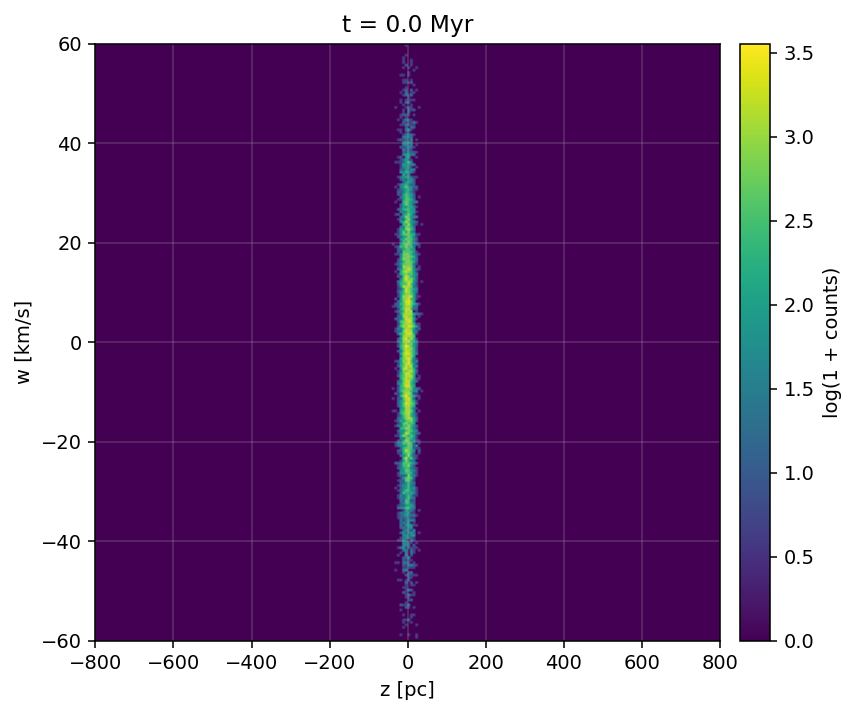

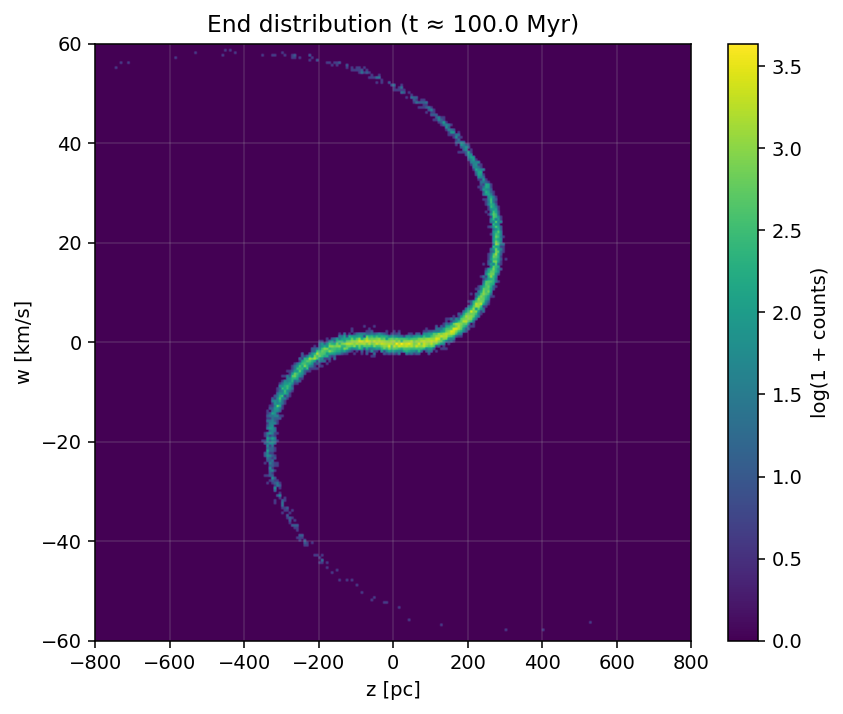

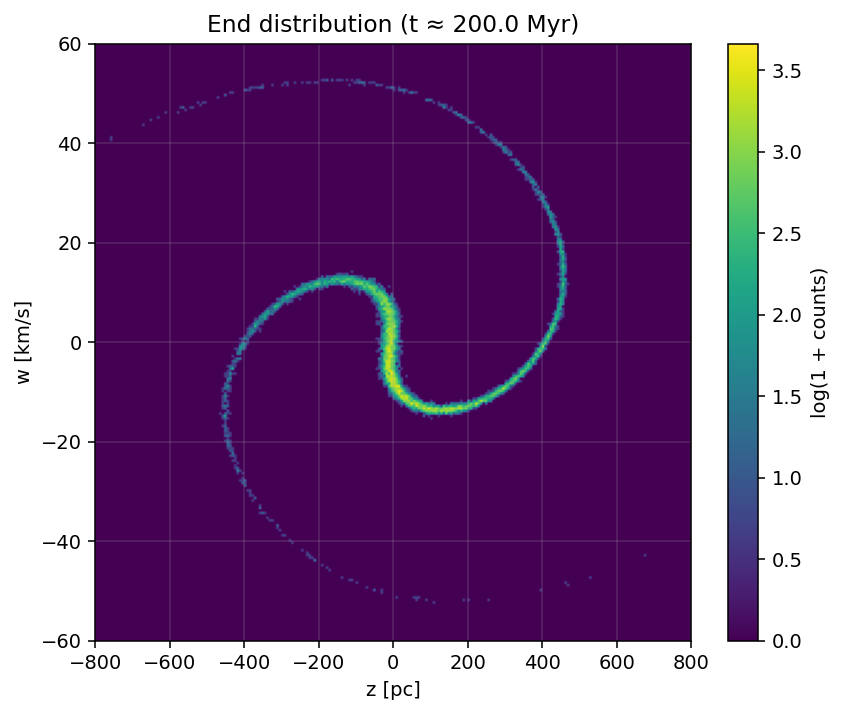

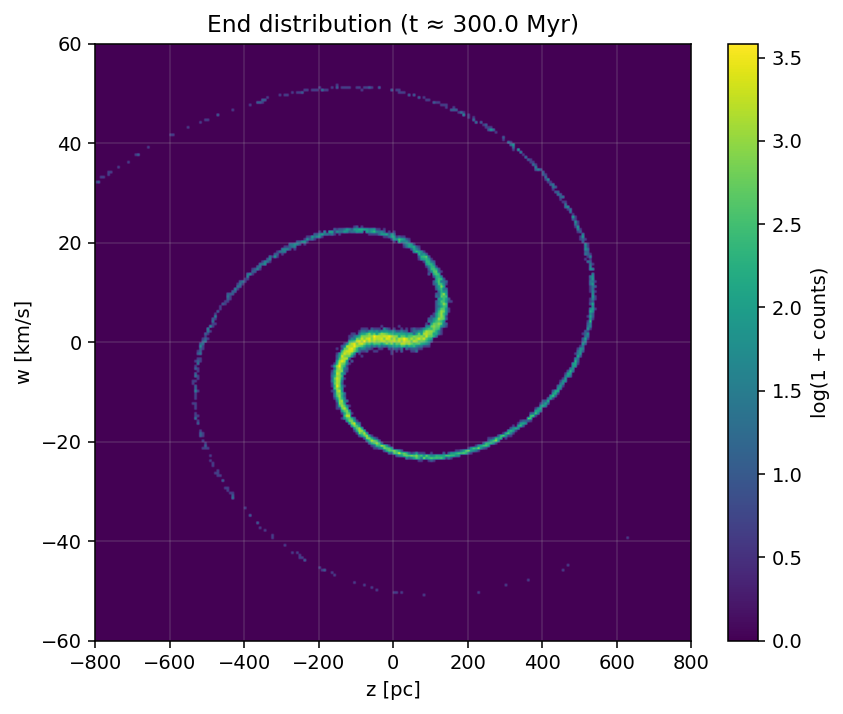

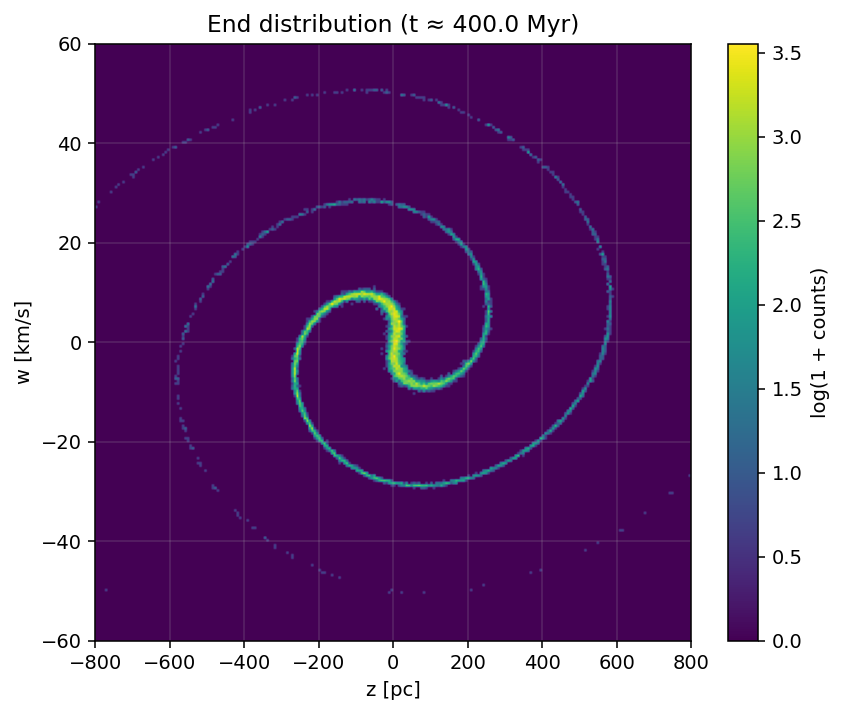

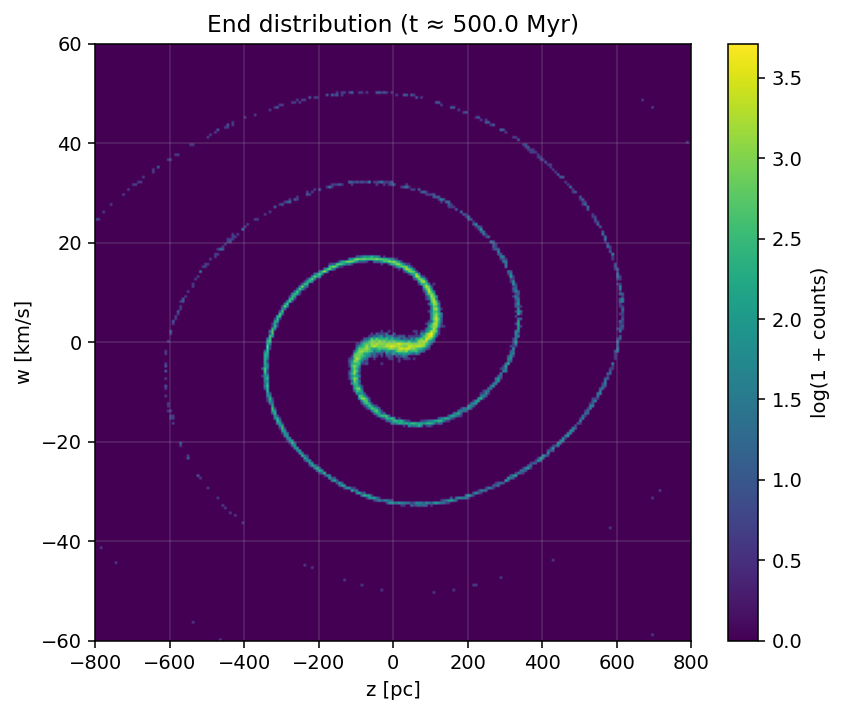

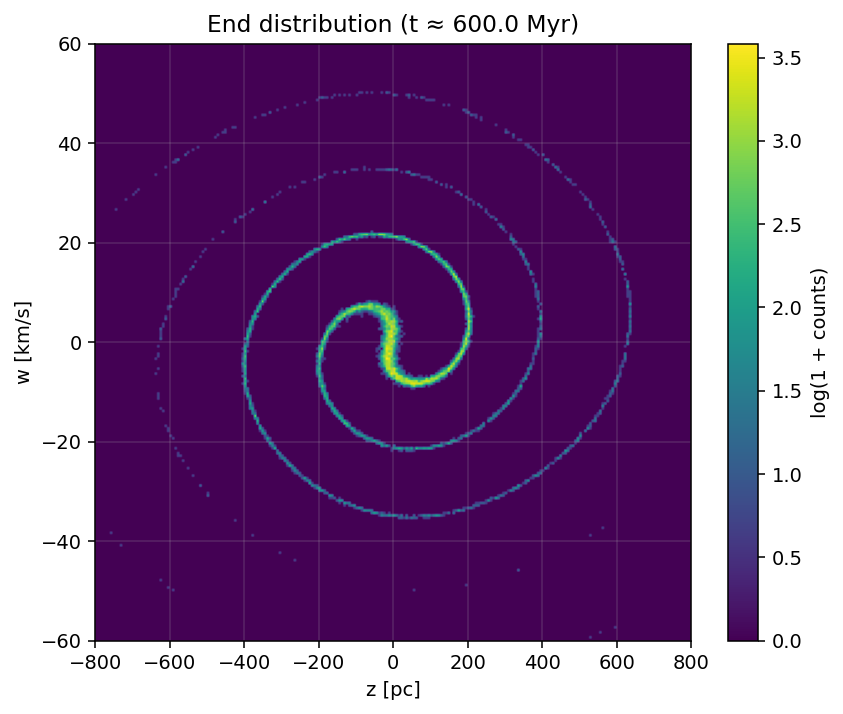

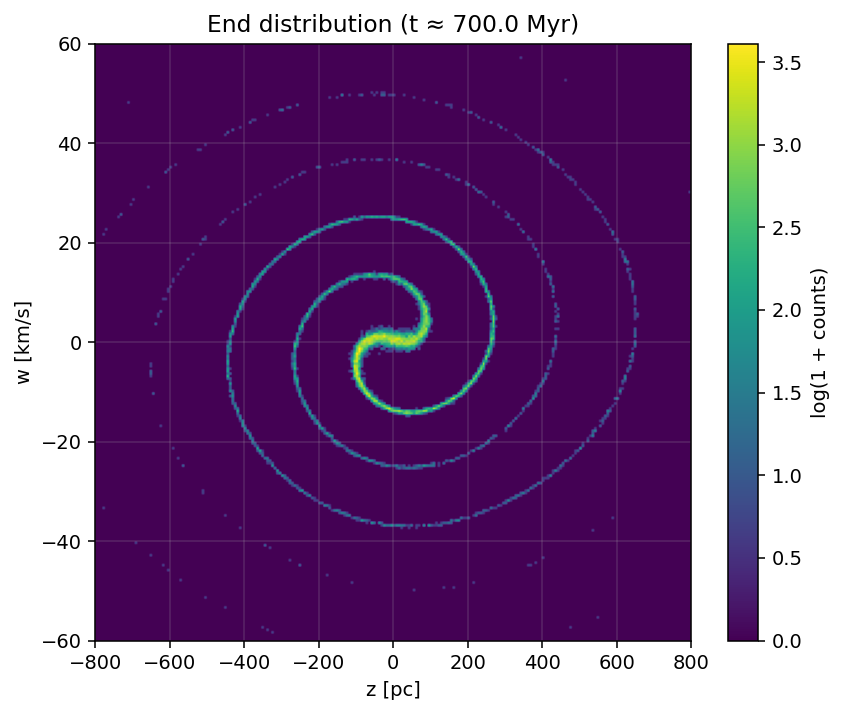

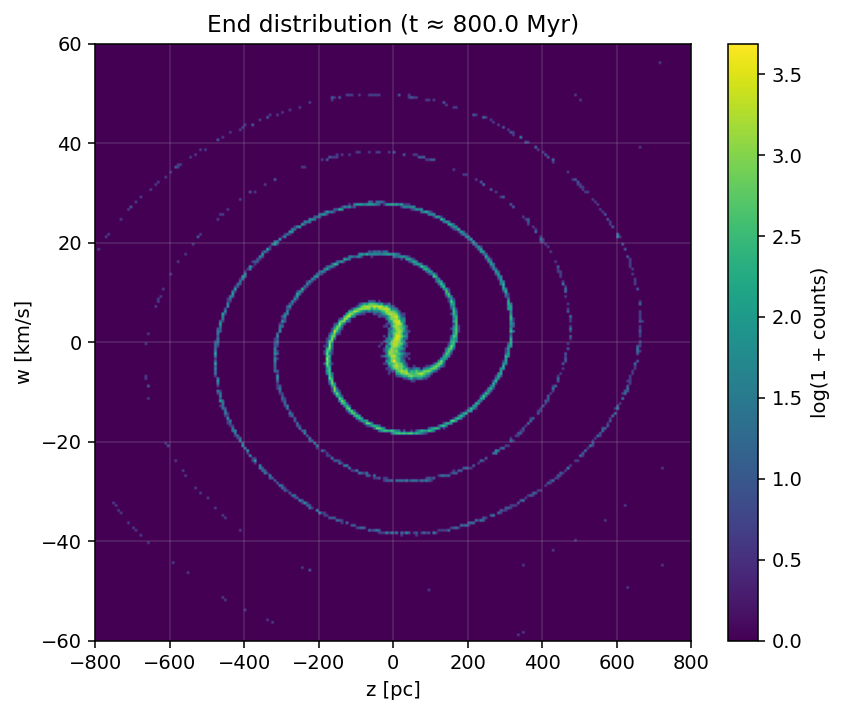

In [5]:
# ==========================================================
# Example: starting distribution (via animation at t=0),
#          then end distribution, then fluctuations map
# ==========================================================
t_obs = np.linspace(100,800,8)
# t_obs = [800]
for i, t in enumerate(t_obs):
    sim = Widmark1DSimulation()
    ana = Widmark1DAnalysis(sim)

    # start distribution (you said you already have this via the animation)
    z0, w0 = sim.sample_near_midplane(N=10_000, z_sigma_pc=10, w_sigma_kms=20.0, seed=None)

    Zs, Ws, Ts_myr = sim.evolve_with_satellite_record(
        z0, w0, t_obs_myr=t, n_steps=25_000, n_snaps=90, seed=None, use_satellite=True, harmonic=False
    )
    if i==0:
        # 1) starting distribution as an animation (frame 0)
        fig, ani = ana.animate_phase_space_hist(
            Zs, Ws, Ts_myr, z_lim=800.0, w_lim=60.0, nbins=240, use_log=True
        )
        plt.show()

    # 2) NEW: end distribution (final histogram)
    ana.plot_end_distribution(
        Zs[-1], Ws[-1],
        z_lim=800.0, w_lim=60.0, nbins=240, use_log=True,
        title=f"End distribution (t ≈ {Ts_myr[-1]:.1f} Myr)"
    )

    show_fluc = False
    if i==0 and show_fluc==True:
        # 3) fluctuations around the mean (spiral map)
        z_bins = np.linspace(-700, 700, 220)
        w_bins = np.linspace(-60, 60, 220)
        ana.plot_spiral_map(
            Zs[-1], Ws[-1],
            z_bins=z_bins, w_bins=w_bins,
            n_gmm=6, random_state=0
        )

    # Optional save:
    # ani.save("phase_space_spiral.mp4", fps=25)  # needs ffmpeg


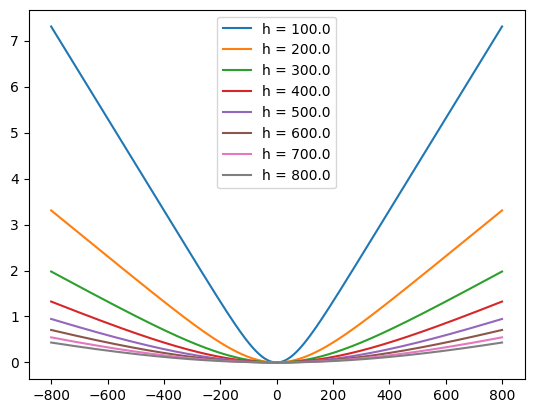

In [51]:
hs = np.linspace(100, 800, 8)
x = np.linspace(-800,800,10_000)
for h in hs:
    y = np.log(np.cosh(x/h))
    plt.plot(x, y, label=f"h = {h}")
plt.legend()